# Dependencies and random seed

In [ ]:
import random
import shutil
import numpy as np
import pandas as pd
import requests
import time
import importlib.metadata
import sys
from itertools import combinations

import mygene
from biomart import BiomartServer
from Bio.KEGG import REST
from cmapPy.pandasGEXpress.parse import parse

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import TensorDataset

In [ ]:
def set_random_seed(seed: int):
    """Set random seed for reproducibility across multiple libraries."""
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

In [ ]:
base_dir = "/project2/liangche_105/yinq/xNNPCD"  # Please update path before running

In [ ]:
packages = [
    "numpy", "pandas", "requests", "mygene", "biomart",
    "biopython", "cmapPy", "matplotlib", "seaborn",
    "scipy", "scikit-learn", "torch"
]

print(f"Python version: {sys.version.split()[0]}")
print("-" * 30)
print(f"{'Package':<20} {'Version'}")
print("-" * 30)

for pkg in packages:
    try:
        version = importlib.metadata.version(pkg)
        print(f"{pkg:<20} {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{pkg:<20} Not Found")

Python version: 3.11.9
------------------------------
Package              Version
------------------------------
numpy                1.26.4
pandas               2.2.3
requests             2.32.3
mygene               3.2.2
biomart              0.9.2
biopython            1.84
cmapPy               4.0.1
matplotlib           3.10.0
seaborn              0.13.2
scipy                1.11.2
scikit-learn         1.6.1
torch                2.6.0+cpu


# Data

## CMap data preparation

Here, we handle the raw CMap and DepMap data. This includes parsing GCT files, mapping gene knockouts to their corresponding cell lines, aligning dependency scores, and translating gene IDs to human-readable symbols.

### Raw processing

In [ ]:
# Parse GCT data and extract data matrix, row, and column metadata
gct_data = parse(base_dir + "/data/level5_beta_trt_xpr_n142901x12328.gctx")
data_matrix = gct_data.data_df.T
row_metadata = gct_data.row_metadata_df
col_metadata = gct_data.col_metadata_df

/home1/yinq/.local/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/home1/yinq/.local/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


In [ ]:
# Load signature info and merge with data matrix index to create sample info
sig_info = pd.read_table(base_dir + "/data/siginfo_beta.txt")
sig_info = sig_info[['sig_id', 'cell_iname', 'cmap_name']]
index_df = pd.DataFrame(data_matrix.index)
index_df.columns = ['sig_id']
sample_info = index_df.merge(sig_info, on='sig_id', how='left')
sample_info.set_index('sig_id', inplace=True)

/tmp/SLURM_3295513/ipykernel_1308068/1682342382.py:2: DtypeWarning: Columns (0,3,4,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  sig_info = pd.read_table(base_dir + "/data/siginfo_beta.txt")


In [ ]:
# Load CRISPR DepMap data and map it to corresponding cell lines
depmap = pd.read_csv(base_dir + "/data/CRISPRGeneEffect.csv", index_col=0)
depmap_cell_line = pd.read_csv(base_dir + "/data/Model.csv", index_col=0)

# Filter matched cell lines and remove duplicates to ensure unique indices
matched_cell_line = depmap_cell_line[depmap_cell_line['StrippedCellLineName'].isin(sample_info['cell_iname'].unique())]
matched_cell_line = matched_cell_line.drop_duplicates(subset=['StrippedCellLineName'])

depmap = depmap.loc[matched_cell_line.index]
depmap.index = matched_cell_line['StrippedCellLineName']

# Clean gene names in columns (vectorized)
depmap.columns = [col.split(' ')[0] for col in depmap.columns]

# Optimize mapping using pandas stack and merge instead of slow loops
depmap_long = depmap.stack().reset_index()
depmap_long.columns = ['cell_iname', 'cmap_name', 'dependency']

# Merge with sample_info to map dependencies efficiently
sample_info_reset = sample_info.reset_index()
sample_info_merged = sample_info_reset.merge(depmap_long, on=['cell_iname', 'cmap_name'], how='inner')
sample_info_merged.set_index('sig_id', inplace=True)

# Update sample_info and align data_matrix
sample_info = sample_info_merged
data_matrix = data_matrix.loc[sample_info.index]

In [ ]:
# Translate Entrez Gene IDs to Gene Symbols using MyGeneInfo
mg = mygene.MyGeneInfo()
gene_id = list(data_matrix.columns)
gene_info = mg.querymany(gene_id, scopes="entrezgene", fields="symbol", species="human")

# Hardcode specific mappings for genes with missing or outdated symbols
gene_names = [
    "UPK3B" if result["query"] == "80761" else
    "TMEM257" if result["query"] == "9142" else
    "OCLM" if result["query"] == "10896" else
    "KIAA1107" if result["query"] == "23285" else
    "LOC100507424" if result["query"] == "100507424" else
    "DGCR9" if result["query"] == "25787" else
    "LINC00341" if result["query"] == "79686" else
    "C10orf12" if result["query"] == "26148" else
    "CTAGE5" if result["query"] == "117153" else
    result.get("symbol", "Not found")
    for result in gene_info
]

# Rename columns
data_matrix.columns = gene_names

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
9 input query terms found no hit:	['80761', '9142', '10896', '23285', '100507424', '25787', '79686', '26148', '117153']


In [ ]:
# Save parsed data
data_matrix.to_parquet(base_dir + "/data/data_matrix.parquet", engine='pyarrow', compression='snappy')
sample_info.to_csv(base_dir + "/data/sample_info.csv")

### Directly load

In [ ]:
# Load preprocessed CMap data and sample information
data_matrix = pd.read_parquet(base_dir + "/data/data_matrix.parquet", engine='pyarrow')
sample_info = pd.read_csv(base_dir + "/data/sample_info.csv", index_col=0)

In [ ]:
data_matrix

,DDR1,PAX8,GUCA1A,EPHB3,ESRRA,TRADD,PRPF8,CAPNS1,RPL35,RPL28,...,RABEP2,ZNF783,CX3CL1,NPEPL1,ADAP1,LRCH4,MEX3D,EPS8L1,DCAF15,ACTB
sig_id,,,,,,,,,,,,,,,,,,,,,
XPR038_A549.311_96H:A03,-0.397990,-1.161871,-0.277472,-0.908711,-0.200055,0.727984,-0.359592,1.197255,-0.528946,-0.597297,...,0.641625,0.842982,0.255705,1.257802,-0.735888,-0.162468,-0.795937,0.206143,-0.586715,0.045168
XPR038_A549.311_96H:A04,0.142264,-0.361102,-1.190112,-0.304021,0.504097,-0.853843,0.534403,0.799773,0.992185,0.951725,...,0.416670,-0.066925,-0.943430,-0.516192,-0.891917,0.194514,-0.067918,-1.534017,-0.375866,0.571839
XPR038_A549.311_96H:A07,0.164016,-0.169961,0.411186,0.402940,0.177294,0.370245,-0.861731,-0.021516,-1.414892,-1.562262,...,0.576748,-0.309744,0.676438,-0.016527,1.118088,-0.529307,0.045210,0.592331,0.858150,-0.501123
XPR038_A549.311_96H:A08,1.007527,1.013682,0.616334,0.513586,-0.002214,-0.103404,0.288145,-0.581552,-0.336615,-0.782781,...,0.276564,-0.166407,0.900589,0.443247,0.928661,-0.552736,0.699309,-0.036806,0.776184,-0.628008
XPR038_A549.311_96H:A09,0.653676,0.732813,1.233061,-0.474156,0.672511,1.159554,-1.121324,0.273131,-0.409050,-0.976458,...,0.636909,-0.424115,1.308922,1.240803,1.170765,-0.187219,0.551582,0.627547,0.100989,-0.839779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTO.XPR001_U937_408H:PDS5B:-666,-0.004768,-0.387401,-0.074463,0.292352,0.118912,0.485354,0.153307,0.080555,-0.019592,-0.008225,...,-0.272582,0.523412,0.029466,0.100825,0.035516,-0.407064,-0.188391,-0.219046,0.031551,-0.261115
ZTO.XPR001_U937_408H:RAD21:-666,0.119435,-0.052151,0.034490,0.462498,0.080506,-0.308145,0.157674,-0.070768,0.052733,-0.233933,...,-0.491353,0.061671,0.050510,0.338490,0.103480,-0.340172,-0.130577,0.199788,-0.113544,-0.122878
ZTO.XPR001_U937_408H:SMC1A:-666,0.433973,-0.155700,0.283306,0.385998,0.122677,-0.012469,-0.113129,-0.020955,-0.332076,-0.483981,...,0.145222,-0.458931,0.476485,0.657053,-0.116633,-0.230139,-0.464519,0.965128,-0.175643,-0.477394


In [ ]:
sample_info

,cell_iname,cmap_name,dependency
sig_id,,,
XPR038_A549.311_96H:A03,A549,COASY,-0.139782
XPR038_A549.311_96H:A04,A549,ASAH1,0.186927
XPR038_A549.311_96H:A07,A549,KDM5A,-0.219258
XPR038_A549.311_96H:A08,A549,SIRT3,-0.058560
XPR038_A549.311_96H:A09,A549,CRBN,-0.004304
...,...,...,...
ZTO.XPR001_U937_408H:PDS5B:-666,U937,PDS5B,-0.007917
ZTO.XPR001_U937_408H:RAD21:-666,U937,RAD21,-1.269226
ZTO.XPR001_U937_408H:SMC1A:-666,U937,SMC1A,-1.911899


## Constructing original mask matrix

This section builds the biological prior knowledge mask. We query databases like GO, KEGG, and Reactome to identify genes associated with the five PCD pathways (apoptosis, autophagy, ferroptosis, necroptosis, pyroptosis). This binary mask will guide the first layer of our neural network.

### Raw processing

In [ ]:
# Connect to Ensembl Biomart for pathway mapping
server = BiomartServer("http://useast.ensembl.org/biomart")
mart = server.datasets['hsapiens_gene_ensembl']

In [ ]:
# Fetching PCD gene list from GO terms
pathway_id = ['GO:0141201', 'GO:0097707', 'GO:0048102', 'GO:0097300', 'GO:0006915']
pathway_name = ['pyroptosis', 'ferroptosis', 'autophagy', 'necroptosis', 'apoptosis']

attributes = [
    'ensembl_gene_id',        # Gene stable ID
    'external_gene_name',     # Gene name
    'go_id'                   # GO term accession
]

gene_go_pcd = pd.DataFrame(columns=['Gene stable ID', 'Gene name', 'Pathway ID', 'Pathway name'])

# Query Ensembl Biomart for genes associated with specific GO terms
for i in range(len(pathway_id)):
    pid, pname = pathway_id[i], pathway_name[i]
    response = mart.search({
        'attributes': attributes,
        'filters': {
            'go': pid
        }
    })
    lines = response.text.strip().split("\n")
    data = [line.split("\t") for line in lines]
    if data[0] == ['']:
        continue
    df = pd.DataFrame(data, columns=[
        'Gene stable ID', 'Gene name', 'Pathway ID'
    ])
    df = df.loc[df['Pathway ID'] == pid].copy()
    df['Pathway name'] = pname
    gene_go_pcd = pd.concat([gene_go_pcd, df], ignore_index=True)

In [ ]:
# Fetching PCD gene list from KEGG Pathways
pathway_id = ['hsa04210', 'hsa04217', 'hsa04216', 'hsa04140']
pathway_name = ['apoptosis', 'necroptosis', 'ferroptosis', 'autophagy']

gene_kegg_pcd = pd.DataFrame(columns=['Gene Entrez ID', 'Gene name', 'Pathway ID', 'Pathway name'])

# Query KEGG REST API for genes in specific pathways
for i in range(len(pathway_id)):
    pid, pname = pathway_id[i], pathway_name[i]
    response = REST.kegg_get(pid)
    kegg_data = response.read()

    if not kegg_data:
        continue

    flag = False
    gene_lines = kegg_data.split('\n')
    for line in gene_lines:
        if line.startswith("GENE"):
            flag = True
            line = line.replace("GENE        ", "")
        elif line.startswith("COMPOUND"):
            flag = False

        if flag:
            while line.startswith(" "):
                line = line[1:]
            parts = line.split(' ', 1)
            gene_id = parts[0]
            gene_info = parts[1] if len(parts) > 1 else ""
            gene_name = gene_info.split(';')[0].strip() if ';' in gene_info else gene_info

            df = pd.DataFrame([{
                'Gene Entrez ID': gene_id,
                'Gene name': gene_name,
                'Pathway ID': pid,
                'Pathway name': pname
            }])
            gene_kegg_pcd = pd.concat([gene_kegg_pcd, df], ignore_index=True)

# Map Entrez IDs to Ensembl IDs for consistency
entrez_ids = list(gene_kegg_pcd['Gene Entrez ID'].unique())
attributes = [
    'entrezgene_id',       # Entrez Gene ID
    'ensembl_gene_id',     # Gene stable ID
]

response = mart.search({
    'filters': {
        'entrezgene_id': entrez_ids
    },
    'attributes': attributes
})

lines = response.text.strip().split("\n")
data = [line.split("\t") for line in lines if line.strip()]
gene_map = pd.DataFrame(data, columns=['Entrez Gene ID', 'Gene stable ID'])

# Merge mapping and clean up
merged_df = pd.merge(gene_kegg_pcd, gene_map, left_on='Gene Entrez ID', right_on='Entrez Gene ID', how='left')
gene_kegg_pcd = merged_df[['Gene stable ID', 'Gene name', 'Pathway ID', 'Pathway name']].copy()
gene_kegg_pcd = gene_kegg_pcd.dropna(subset=['Gene stable ID'])

In [ ]:
# Fetching PCD gene list from Reactome Pathways
pathway_id = ['R-HSA-109581', 'R-HSA-5213460', 'R-HSA-5620971']
pathway_name = ['apoptosis', 'necroptosis', 'pyroptosis']

attributes = [
    'ensembl_gene_id',         # Gene stable ID
    'external_gene_name',      # Gene name
    'reactome'                 # Pathway ID (Reactome ID)
]

gene_reactome_pcd = pd.DataFrame(columns=['Gene stable ID', 'Gene name', 'Pathway ID', 'Pathway name'])

# Query Ensembl Biomart for Reactome pathways
for i in range(len(pathway_id)):
    pid, pname = pathway_id[i], pathway_name[i]
    response = mart.search({
        'attributes': attributes,
        'filters': {
            'reactome': pid
        }
    })
    lines = response.text.strip().split("\n")
    data = [line.split("\t") for line in lines]
    if data[0] == ['']:
        continue
    df = pd.DataFrame(data, columns=[
        'Gene stable ID', 'Gene name', 'Pathway ID'
    ])
    df = df.loc[df['Pathway ID'] == pid].copy()
    df['Pathway name'] = pname
    gene_reactome_pcd = pd.concat([gene_reactome_pcd, df], ignore_index=True)

In [ ]:
# Combine all queried genes into a single PCD gene dataset
gene_pcd = pd.concat([gene_go_pcd, gene_kegg_pcd, gene_reactome_pcd], axis=0, ignore_index=True)
gene_pcd = gene_pcd[~gene_pcd.duplicated(subset=['Gene stable ID', 'Gene name', 'Pathway name'])]
gene_pcd = gene_pcd.sort_values(by="Pathway name").reset_index(drop=True)

# Save the combined PCD gene list
gene_pcd.to_csv(base_dir + "/results/gene_pcd.csv")

### Directly load

In [ ]:
# Load PCD related genes
gene_pcd = pd.read_csv(base_dir + "/results/gene_pcd.csv", index_col=0)

In [ ]:
# Identify common death and knocked-out genes between datasets
common_death_genes = set(gene_pcd['Gene name']) & set(data_matrix.columns)
common_ko_genes = set(sample_info['cmap_name'].unique()) & set(data_matrix.columns)

gene_death = sorted(list(common_death_genes))
gene_ko = sorted(list(common_ko_genes))

With the PCD gene list ready, we create a binary mask matrix mapping our dataset's genes to their respective PCD pathways, adding an 'others' category for unknown functions.

In [ ]:
# Construct original binary mask matrix based on prior knowledge (PCD pathways)
pathways = sorted(list(set(gene_pcd['Pathway name'])))
mask_original = pd.DataFrame(0, index=data_matrix.columns, columns=pathways)

for i in range(gene_pcd.shape[0]):
    gene_name = gene_pcd.iloc[i, 1]
    pathway_name = gene_pcd.iloc[i, 3]
    if gene_name in mask_original.index:
        mask_original.loc[gene_name, pathway_name] = 1

# Add 'others' category to account for unknown functions
mask_original['others'] = 1

# Save the original mask matrix
# mask_original.to_csv(base_dir + "/results/mask_original.csv")

In [ ]:
mask_original

,apoptosis,autophagy,ferroptosis,necroptosis,pyroptosis,others
DDR1,0,0,0,0,0,1
PAX8,0,0,0,0,0,1
GUCA1A,0,0,0,0,0,1
EPHB3,0,0,0,0,0,1
ESRRA,0,0,0,0,0,1
...,...,...,...,...,...,...
LRCH4,0,0,0,0,0,1
MEX3D,0,0,0,0,0,1
EPS8L1,0,0,0,0,0,1
DCAF15,0,0,0,0,0,1


## Splitting data

Before training, we split our data into training, validation, and testing sets to ensure our model generalizes well to unseen data.

In [ ]:
# Split data into train, validation, and test sets (80-10-10 split)
X_train, X_temp, y_train, y_temp = train_test_split(
    data_matrix, sample_info['dependency'], test_size=0.2, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED
)

# Combine train and val sets for the final retraining phase
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

In [ ]:
# Ensure all target variables are numeric
y_train = pd.to_numeric(y_train, errors='coerce')
y_val = pd.to_numeric(y_val, errors='coerce')
y_train_final = pd.to_numeric(y_train_final, errors='coerce')
y_test = pd.to_numeric(y_test, errors='coerce')

# xNNPCD

xNNPCD is an interpretable neural network framework for discovering regulators of programmed cell death. It is built upon a base interpretable multi-layer perceptron and introduces an iterative mask refinement mechanism. It uses pathway ablation to identify newly discovered gene-pathway relationships and updates the soft mask accordingly.

## Neural network definition

We define the neural network structure (`MaskedMLP_Regression`). In the neural network, we apply the mask matrix to the first hidden layer to constrain the weights. This ensures that the genes only contribute to their specific PCD pathways, effectively embedding our biological prior knowledge directly into the network architecture.

In [ ]:
class MaskedMLP_Regression(nn.Module):
    """
    Custom Multi-Layer Perceptron (MLP) for regression tasks,
    incorporating a biological prior knowledge mask.
    """
    def __init__(self, gene_number, mask):
        super(MaskedMLP_Regression, self).__init__()
        self.fc1 = nn.Linear(gene_number, 6)  # First layer: maps genes to 6 pathway nodes
        self.fc2 = nn.Linear(6, 1)            # Second layer: maps pathway nodes to a single dependency score
        self.act = nn.ReLU()
        # Register the pathway mask as a buffer (moved to device, not updated by optimizer)
        self.register_buffer("mask", torch.tensor(mask.values, dtype=torch.float32))
        self.initialize_weights()

    def initialize_weights(self):
        # Initialize model weights using Kaiming uniform and biases with zeros
        nn.init.kaiming_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        # Apply the biological mask to the first layer's weights for pathway contraints
        masked_weight = self.fc1.weight * self.mask.T
        pre_activation = nn.functional.linear(x, masked_weight, self.fc1.bias)
        post_activation = self.act(pre_activation)
        logit = self.fc2(post_activation)
        return logit, post_activation

## Hyperparameter tuning

### Hyperparameters for neural network

We perform a grid search over learning rates, weight decays, and batch sizes to find the optimal configuration using early stopping on the validation set. In this stage, the mask matrix is fixed to `mask_original`.

In [ ]:
# Convert data to PyTorch tensors for hyperparameter tuning
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

In [ ]:
learning_rates = [1e-2, 1e-3, 1e-4]
weight_decays = [0, 1e-5, 1e-4, 1e-3]
batch_sizes = [128, 256, 512]
early_stopping_patience = 10

In [ ]:
def train_and_validate_regression(lr, weight_decay, batch_size):
    # Set up generator and device
    g = torch.Generator()
    g.manual_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Prepare data loaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)

    # Initialize model, loss, and optimizer
    model = MaskedMLP_Regression(gene_number=X_train.shape[1], mask=mask_original).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Learning rate scheduler and early stopping setup
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    best_val_loss = float('inf')
    epochs_no_improve = 0

    num_epochs = 200
    for epoch in range(num_epochs):
        # Training loop
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output, _ = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

        # Validation loop
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                output, _ = model(X_val_batch)
                loss = criterion(output, y_val_batch)
                val_loss += loss.item() * X_val_batch.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss:.4f}")

        scheduler.step()

        # Early stopping check and model saving
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    return best_val_loss

In [ ]:
best_params = {}
best_overall_val_loss = float('inf')

# Grid search over hyperparameters
for lr in learning_rates:
    for wd in weight_decays:
        for bs in batch_sizes:
            print(f"--- Testing params: lr={lr}, wd={wd}, bs={bs} ---")
            set_random_seed(RANDOM_SEED)
            current_val_loss = train_and_validate_regression(lr, wd, bs)

            # Update overall best if current model improves validation loss
            if current_val_loss < best_overall_val_loss:
                best_overall_val_loss = current_val_loss
                best_params = {'lr': lr, 'weight_decay': wd, 'batch_size': bs}
                print(f"*** New OVERALL best params found: {best_params} with val_loss: {best_overall_val_loss:.4f} ***\n")

print(f"Grid search finished. The best hyperparameters are: {best_params}")

--- Testing params: lr=0.01, wd=0, bs=128 ---
Epoch 1 | Val Loss: 0.1539
Epoch 2 | Val Loss: 0.1513
Epoch 3 | Val Loss: 0.1514
Epoch 4 | Val Loss: 0.1510
Epoch 5 | Val Loss: 0.1486
Epoch 6 | Val Loss: 0.1468
Epoch 7 | Val Loss: 0.1486
Epoch 8 | Val Loss: 0.1485
Epoch 9 | Val Loss: 0.1469
Epoch 10 | Val Loss: 0.1468
Epoch 11 | Val Loss: 0.1467
Epoch 12 | Val Loss: 0.1456
Epoch 13 | Val Loss: 0.1463
Epoch 14 | Val Loss: 0.1469
Epoch 15 | Val Loss: 0.1467
Epoch 16 | Val Loss: 0.1463
Epoch 17 | Val Loss: 0.1460
Epoch 18 | Val Loss: 0.1452
Epoch 19 | Val Loss: 0.1455
Epoch 20 | Val Loss: 0.1457
Epoch 21 | Val Loss: 0.1455
Epoch 22 | Val Loss: 0.1457
Epoch 23 | Val Loss: 0.1456
Epoch 24 | Val Loss: 0.1458
Epoch 25 | Val Loss: 0.1456
Epoch 26 | Val Loss: 0.1456
Epoch 27 | Val Loss: 0.1454
Epoch 28 | Val Loss: 0.1456
Early stopping triggered after 28 epochs!
*** New OVERALL best params found: {'lr': 0.01, 'weight_decay': 0, 'batch_size': 128} with val_loss: 0.1452 ***

--- Testing params: lr=0

The best hyperparameters are: learning_rate = 0.01, weight_decay = 0.001, batch_size = 128, epoch = 43.

### Hyperparameters for mask updating

We tune the lambda and beta hyperparameters for the mask updating mechanism using the training and validation sets.

In [ ]:
final_bs = 128
final_lr = 0.01
final_wd = 0.001
final_epochs = 43

lambda_list = [0.0, 0.1, 0.3, 0.5, 1.0]
beta_list = [0.1, 0.5, 0.9]

In [ ]:
pcd_pathways = mask_original.columns[0:5]
all_ko_genes = sample_info['cmap_name'].unique()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_global_val_r2 = -999
best_hyperparams = {}

# Perform grid search over lambda and beta hyperparameters
for lam in lambda_list:
    for beta in beta_list:
        print(f"\nTesting Lambda={lam}, Beta={beta}...")

        prev_model = None
        best_run_r2 = -999
        best_iter = 0
        patience = 0
        patience_limit = 2

        # Initialize soft masks for the current hyperparameter setting
        current_soft_mask = mask_original.copy().astype(float)
        prev_soft_mask = current_soft_mask.copy()

        for it in range(10):
            set_random_seed(RANDOM_SEED)
            g = torch.Generator()
            g.manual_seed(RANDOM_SEED)

            # Re-initialize data loaders for each iteration to maintain consistency
            train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=final_bs, shuffle=True, generator=g)
            val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=final_bs, shuffle=False)

            # Initialize a fresh model with the updated soft mask
            new_model = MaskedMLP_Regression(X_train.shape[1], current_soft_mask).to(device)

            # Transfer weights from the previous iteration's model if available
            if prev_model is not None:
                with torch.no_grad():
                    new_model.fc1.weight.copy_(prev_model.fc1.weight)
                    new_model.fc1.bias.copy_(prev_model.fc1.bias)
                    new_model.fc2.weight.copy_(prev_model.fc2.weight)
                    new_model.fc2.bias.copy_(prev_model.fc2.bias)

            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(new_model.parameters(), lr=final_lr, weight_decay=final_wd)
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

            # Train the model
            new_model.train()
            for epoch in range(final_epochs):
                for X_b, y_b in train_loader:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    optimizer.zero_grad()
                    output, _ = new_model(X_b)
                    loss = criterion(output, y_b)
                    loss.backward()
                    optimizer.step()
                scheduler.step()

            # Evaluate the model on the validation set
            new_model.eval()
            with torch.no_grad():
                val_preds = []
                val_labels = []
                for X_b, y_b in val_loader:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    output, _ = new_model(X_b)
                    val_preds.append(output.cpu())
                    val_labels.append(y_b.cpu())

                val_preds = torch.cat(val_preds)
                val_labels = torch.cat(val_labels)
                val_r2 = r2_score(val_labels, val_preds)

            print(f"  Iter {it+1}: Val R2 = {val_r2:.4f}")

            # Check for early stopping based on validation R2
            if val_r2 > best_run_r2:
                best_run_r2 = val_r2
                best_iter = it + 1
                patience = 0
            else:
                patience += 1

            if patience >= patience_limit:
                print(f"Early stopping. Best Iter was {best_iter}")
                break

            # Mask Refinement Process via Pathway Ablation
            ablation_results = []
            for ko_gene in all_ko_genes:
                # Find instances where the specific gene was knocked out
                mask_pd = (sample_info.loc[X_train.index]['cmap_name'] == ko_gene)
                indices = np.where(mask_pd.to_numpy())[0]
                if len(indices) == 0:
                    continue

                # Extract corresponding expressions and move to device
                ko_gene_tensor = torch.tensor(X_train.iloc[indices].to_numpy(), dtype=torch.float32).to(device)

                with torch.no_grad():
                    # Calculate original predictions
                    logits_original, post_activations_original = new_model(ko_gene_tensor)
                    avg_score_original = torch.mean(logits_original).item()
                    gene_importance_scores = {'ko_gene': ko_gene}

                    # Evaluate the importance of each PCD pathway
                    for i, pathway_name in enumerate(pcd_pathways):
                        post_activations_ablated = post_activations_original.clone()
                        post_activations_ablated[:, i] = 0.0  # Ablate the specific pathway
                        logits_ablated = new_model.fc2(post_activations_ablated)
                        avg_score_ablated = torch.mean(logits_ablated).item()

                        # Importance is the absolute difference in predictions
                        importance = abs(avg_score_original - avg_score_ablated)
                        gene_importance_scores[pathway_name] = importance

                    ablation_results.append(gene_importance_scores)

            ablation_results_df = pd.DataFrame(ablation_results)

            # Construct a new importance matrix for all genes and pathways
            imp_matrix_df = pd.DataFrame(0.0, index=mask_original.index, columns=mask_original.columns)
            for pathway in imp_matrix_df.columns:
                if pathway in ablation_results_df.columns:
                    imp_series = ablation_results_df.set_index('ko_gene')[pathway]
                    common_genes = imp_matrix_df.index.intersection(imp_series.index)
                    if len(common_genes) > 0:
                        imp_matrix_df.loc[common_genes, pathway] = imp_series.loc[common_genes]

            # Normalize importance scores to [0, 1] range per pathway
            normalized_imp_df = imp_matrix_df.copy()
            for col in normalized_imp_df.columns:
                mn, mx = normalized_imp_df[col].min(), normalized_imp_df[col].max()
                if mx > mn:
                    normalized_imp_df[col] = (normalized_imp_df[col] - mn) / (mx - mn)
            if 'others' in normalized_imp_df.columns:
                normalized_imp_df['others'] = 1.0

            # Compute the next soft mask using lambda and beta
            target_mask = (1 - lam) * normalized_imp_df + lam * mask_original
            next_soft_mask = (1 - beta) * target_mask + beta * prev_soft_mask

            prev_model = new_model
            prev_soft_mask = next_soft_mask.copy()
            current_soft_mask = next_soft_mask.copy()

        # Update the best global hyperparameters if the current setup is better
        if best_run_r2 > best_global_val_r2:
            best_global_val_r2 = best_run_r2
            best_hyperparams = {'lambda': lam, 'beta': beta, 'iteration': best_iter}
            print(f"New Global Best: R2={best_run_r2:.4f} (Lambda={lam}, Beta={beta}, Iteration={best_iter})")

print(f"\nGrid Search Completed. Best Parameters: {best_hyperparams}, Best Val R2: {best_global_val_r2}")


Testing Lambda=0.0, Beta=0.1...
  Iter 1: Val R2 = 0.3064
  Iter 2: Val R2 = 0.3263
  Iter 3: Val R2 = 0.3205
  Iter 4: Val R2 = 0.3114
Early stopping. Best Iter was 2
New Global Best: R2=0.3263 (Lambda=0.0, Beta=0.1, Iteration=2)

Testing Lambda=0.0, Beta=0.5...
  Iter 1: Val R2 = 0.3064
  Iter 2: Val R2 = 0.3119
  Iter 3: Val R2 = 0.3185
  Iter 4: Val R2 = 0.3197
  Iter 5: Val R2 = 0.3269
  Iter 6: Val R2 = 0.3247
  Iter 7: Val R2 = 0.3211
Early stopping. Best Iter was 5
New Global Best: R2=0.3269 (Lambda=0.0, Beta=0.5, Iteration=5)

Testing Lambda=0.0, Beta=0.9...
  Iter 1: Val R2 = 0.3064
  Iter 2: Val R2 = 0.3060
  Iter 3: Val R2 = 0.3074
  Iter 4: Val R2 = 0.3173
  Iter 5: Val R2 = 0.3123
  Iter 6: Val R2 = 0.3179
  Iter 7: Val R2 = 0.3206
  Iter 8: Val R2 = 0.3193
  Iter 9: Val R2 = 0.3189
Early stopping. Best Iter was 7

Testing Lambda=0.1, Beta=0.1...
  Iter 1: Val R2 = 0.3064
  Iter 2: Val R2 = 0.3177
  Iter 3: Val R2 = 0.3198
  Iter 4: Val R2 = 0.3254
  Iter 5: Val R2 = 0.3

The best hyperparameters are: lambda = 0, beta = 0.5.

## Model training

Using the optimal hyperparameters, we retrain the final model on the combined training and validation sets.

In [ ]:
# Load optimal hyperparameters
final_bs = 128
final_lr = 0.01
final_wd = 0.001
final_epochs = 43
final_lam = 0
final_beta = 0.5
final_it = 5

In [ ]:
# Set random seed for reproducibility
set_random_seed(RANDOM_SEED)
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

# Convert combined train+val data (final training set) to PyTorch tensors
X_train_final_tensor = torch.tensor(X_train_final.to_numpy(), dtype=torch.float32)
y_train_final_tensor = torch.tensor(y_train_final.to_numpy(), dtype=torch.float32).unsqueeze(1)
train_dataset_final = TensorDataset(X_train_final_tensor, y_train_final_tensor)

In [ ]:
prev_model = None

# Initialize soft masks for the training phase
current_soft_mask = mask_original.copy().astype(float)
prev_soft_mask = current_soft_mask.copy()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for it in range(final_it):
    print(f"Current iteration: {it + 1}")
    set_random_seed(RANDOM_SEED)
    g = torch.Generator()
    g.manual_seed(RANDOM_SEED)

    # Reusing train_dataset_final from the xNN section
    train_loader_final = torch.utils.data.DataLoader(train_dataset_final, batch_size=final_bs, shuffle=True, generator=g)
    new_model = MaskedMLP_Regression(X_train_final.shape[1], current_soft_mask).to(device)

    # Transfer weights from the previous iteration if available
    if prev_model is not None:
        with torch.no_grad():
            new_model.fc1.weight.copy_(prev_model.fc1.weight)
            new_model.fc1.bias.copy_(prev_model.fc1.bias)
            new_model.fc2.weight.copy_(prev_model.fc2.weight)
            new_model.fc2.bias.copy_(prev_model.fc2.bias)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(new_model.parameters(), lr=final_lr, weight_decay=final_wd)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Train the model
    new_model.train()
    for epoch in range(final_epochs):
        for X_b, y_b in train_loader_final:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            output, _ = new_model(X_b)
            loss = criterion(output, y_b)
            loss.backward()
            optimizer.step()
        scheduler.step()

    # Save the final model and mask on the last iteration
    if it == final_it - 1:
        torch.save(new_model.state_dict(), base_dir + '/models/xNNPCD.pth')
        current_soft_mask.to_csv(base_dir + '/results/mask_xNNPCD.csv')
        print("Final iteration model and mask saved.")
        prev_model = new_model
        break

    # Mask Refinement Process via Pathway Ablation
    ablation_results = []
    for ko_gene in all_ko_genes:
        # Find samples corresponding to the knocked-out gene
        mask_pd = (sample_info.loc[X_train_final.index]['cmap_name'] == ko_gene)
        indices = np.where(mask_pd.to_numpy())[0]
        if len(indices) == 0:
            continue

        # Extract gene expressions
        ko_gene_tensor = torch.tensor(X_train_final.iloc[indices].to_numpy(), dtype=torch.float32).to(device)

        with torch.no_grad():
            logits_original, post_activations_original = new_model(ko_gene_tensor)
            avg_score_original = torch.mean(logits_original).item()
            gene_importance_scores = {'ko_gene': ko_gene}

            # Evaluate importance per PCD pathway
            for i, pathway_name in enumerate(pcd_pathways):
                post_activations_ablated = post_activations_original.clone()
                post_activations_ablated[:, i] = 0.0
                logits_ablated = new_model.fc2(post_activations_ablated)
                avg_score_ablated = torch.mean(logits_ablated).item()

                importance = abs(avg_score_original - avg_score_ablated)
                gene_importance_scores[pathway_name] = importance
            ablation_results.append(gene_importance_scores)

    ablation_results_df = pd.DataFrame(ablation_results)

    # Reconstruct and normalize the importance matrix
    imp_matrix_df = pd.DataFrame(0.0, index=mask_original.index, columns=mask_original.columns)
    for pathway in imp_matrix_df.columns:
        if pathway in ablation_results_df.columns:
            imp_series = ablation_results_df.set_index('ko_gene')[pathway]
            common_genes = imp_matrix_df.index.intersection(imp_series.index)
            if len(common_genes) > 0:
                imp_matrix_df.loc[common_genes, pathway] = imp_series.loc[common_genes]

    normalized_imp_df = imp_matrix_df.copy()
    for col in normalized_imp_df.columns:
        mn, mx = normalized_imp_df[col].min(), normalized_imp_df[col].max()
        if mx > mn:
            normalized_imp_df[col] = (normalized_imp_df[col] - mn) / (mx - mn)
    if 'others' in normalized_imp_df.columns:
        normalized_imp_df['others'] = 1.0

    # Update soft mask utilizing exponential moving average and biological prior constraint
    target_mask = (1 - final_lam) * normalized_imp_df + final_lam * mask_original
    next_soft_mask = (1 - final_beta) * target_mask + final_beta * prev_soft_mask

    prev_model = new_model
    prev_soft_mask = next_soft_mask.copy()
    current_soft_mask = next_soft_mask.copy()

Current iteration: 1
Current iteration: 2
Current iteration: 3
Current iteration: 4
Current iteration: 5
Final iteration model and mask saved.


## Model evaluation

We evaluate the final xNNPCD model's performance on the unseen test set using R-squared ($R^2$) and Mean Squared Error (MSE), and visualize the correlation between predicted and true dependency scores.

In [ ]:
# Initialize the model and load the trained weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
new_model = MaskedMLP_Regression(gene_number=X_train_final.shape[1], mask=pd.read_csv(base_dir + "/results/mask_xNNPCD.csv", index_col=0)).to(device)
new_model.load_state_dict(torch.load(base_dir + "/models/xNNPCD.pth", map_location=device))

# Prepare test data tensor dataset
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128)

# Evaluate the model on the testing set
new_model.eval()
with torch.no_grad():
    test_preds_xnnpcd = []
    test_labels_xnnpcd = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output, _ = new_model(X_batch)
        test_preds_xnnpcd.append(output.cpu())
        test_labels_xnnpcd.append(y_batch)

    test_preds_xnnpcd = torch.cat(test_preds_xnnpcd)
    test_labels_xnnpcd = torch.cat(test_labels_xnnpcd)

    r2_xnnpcd = r2_score(test_labels_xnnpcd.numpy(), test_preds_xnnpcd.numpy())
    mse_xnnpcd = mean_squared_error(test_labels_xnnpcd.numpy(), test_preds_xnnpcd.numpy())

print(f"Test Mean Squared Error (MSE): {mse_xnnpcd:.4f}")
print(f"Test R-squared (R²): {r2_xnnpcd:.4f}")

Test Mean Squared Error (MSE): 0.1371
Test R-squared (R²): 0.3061


# Analysis

## Benchmark analysis with RF, MLP, and xNN shows that xNNPCD accurately predicts cell fitness dependency

We evaluate standard machine learning models (RF and MLP) as baselines, and the non-iterative version of xNNPCD (xNN). For RF and MLP, we compare the performance using all features and targeted features (`gene_death` subset).

### RF

In [ ]:
# Train with all available features
rf_reg = RandomForestRegressor(random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train_final, y_train_final)
y_test_pred = rf_reg.predict(X_test)
r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R-squared (R²): {r2:.4f}")

Test Mean Squared Error (MSE): 0.1580
Test R-squared (R²): 0.2004


In [ ]:
# Train with only the "gene_death" feature subset
rf_reg = RandomForestRegressor(random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train_final[gene_death], y_train_final)
y_test_pred = rf_reg.predict(X_test[gene_death])
r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R-squared (R²): {r2:.4f}")

Test Mean Squared Error (MSE): 0.1664
Test R-squared (R²): 0.1581


### MLP

In [ ]:
# Train with all available features
mlp_reg = MLPRegressor(hidden_layer_sizes=(6,), random_state=SEED)
mlp_reg.fit(X_train_final, y_train_final)
y_test_pred = mlp_reg.predict(X_test)
r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R-squared (R²): {r2:.4f}")

Test Mean Squared Error (MSE): 0.1580
Test R-squared (R²): 0.2001


/home1/yinq/.conda/envs/cell_death/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Train with only the "gene_death" feature subset
mlp_reg = MLPRegressor(hidden_layer_sizes=(6,), random_state=SEED)
mlp_reg.fit(X_train_final[gene_death], y_train_final)
y_test_pred = mlp_reg.predict(X_test[gene_death])
r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R-squared (R²): {r2:.4f}")

Test Mean Squared Error (MSE): 0.1468
Test R-squared (R²): 0.2573


### xNN

We reuse the `MaskedMLP_Regression` class and datasets defined earlier to maintain consistency.

In [ ]:
# Set random seed for reproducibility
set_random_seed(RANDOM_SEED)
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

# Hyperparameters obtained from tuning
batch_size = 128
learning_rate = 0.01
weight_decay = 0.001
num_epochs = 43

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader_final = torch.utils.data.DataLoader(train_dataset_final, batch_size=batch_size, shuffle=True, generator=g)

# Initialize the final regression model
final_model = MaskedMLP_Regression(gene_number=X_train_final_tensor.shape[1], mask=mask_original)
final_model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Train the model
print(f"--- Starting final training for {num_epochs} epochs ---")
final_model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for X_batch, y_batch in train_loader_final:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output, _ = final_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader_final)
    print(f"Final training | Epoch {epoch+1}/{num_epochs} | Average Loss: {avg_loss:.4f}")

torch.save(final_model.state_dict(), base_dir + '/models/xNN.pth')
print("Final regression model saved.")

--- Starting final training for 43 epochs ---
Final training | Epoch 1/43 | Average Loss: 0.5896
Final training | Epoch 2/43 | Average Loss: 0.1568
Final training | Epoch 3/43 | Average Loss: 0.3237
Final training | Epoch 4/43 | Average Loss: 0.1713
Final training | Epoch 5/43 | Average Loss: 0.1677
Final training | Epoch 6/43 | Average Loss: 0.1647
Final training | Epoch 7/43 | Average Loss: 0.1611
Final training | Epoch 8/43 | Average Loss: 0.1533
Final training | Epoch 9/43 | Average Loss: 0.1511
Final training | Epoch 10/43 | Average Loss: 0.1516
Final training | Epoch 11/43 | Average Loss: 0.1480
Final training | Epoch 12/43 | Average Loss: 0.1487
Final training | Epoch 13/43 | Average Loss: 0.1498
Final training | Epoch 14/43 | Average Loss: 0.1505
Final training | Epoch 15/43 | Average Loss: 0.1501
Final training | Epoch 16/43 | Average Loss: 0.1462
Final training | Epoch 17/43 | Average Loss: 0.1455
Final training | Epoch 18/43 | Average Loss: 0.1454
Final training | Epoch 19/4

In [ ]:
# Initialize the model and load the trained weights
final_model = MaskedMLP_Regression(gene_number=X_train_final.shape[1], mask=mask_original).to(device)
final_model.load_state_dict(torch.load(base_dir + "/models/xNN.pth", map_location=device))

# Evaluate the model on the testing set (using the same test_loader)
final_model.eval()
with torch.no_grad():
    test_preds_xnn = []
    test_labels_xnn = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output, _ = final_model(X_batch)
        test_preds_xnn.append(output.cpu())
        test_labels_xnn.append(y_batch)

    test_preds_xnn = torch.cat(test_preds_xnn)
    test_labels_xnn = torch.cat(test_labels_xnn)

    r2_xnn = r2_score(test_labels_xnn.numpy(), test_preds_xnn.numpy())
    mse_xnn = mean_squared_error(test_labels_xnn.numpy(), test_preds_xnn.numpy())

print(f"Test Mean Squared Error (MSE): {mse_xnn:.4f}")
print(f"Test R-squared (R²): {r2_xnn:.4f}")

Test Mean Squared Error (MSE): 0.1399
Test R-squared (R²): 0.2920


### Visualization

Here, we aggregate the performance metrics ($R^2$ and MSE) across all tested models. To clearly highlight the improvements, our proposed models are colored in blue, while the baseline models are in grey.

In [ ]:
# Aggregate results from previous training and baseline evaluations
data = {
    'Model': ['xNN', 'xNNPCD', 'RF (All)', 'RF (Death)', 'MLP (All)', 'MLP (Death)'],
    'R2':    [0.29, 0.31, 0.20, 0.16, 0.20, 0.26],
    'MSE': [0.1399, 0.1371, 0.1580, 0.1664, 0.1580, 0.1468],
    'Type':  ['Ours_Basic', 'Ours_Best', 'Benchmark', 'Benchmark', 'Benchmark', 'Benchmark']
}
df = pd.DataFrame(data)

# Define color palette: Blues for our models, Grey for baselines
color_map = {'Ours_Best': '#0052cc', 'Ours_Basic': '#4A90E2', 'Benchmark': '#bdc3c7'}
my_colors = [color_map[t] for t in df['Type']]

/tmp/SLURM_3311483/ipykernel_395812/4185467982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/SLURM_3311483/ipykernel_395812/4185467982.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


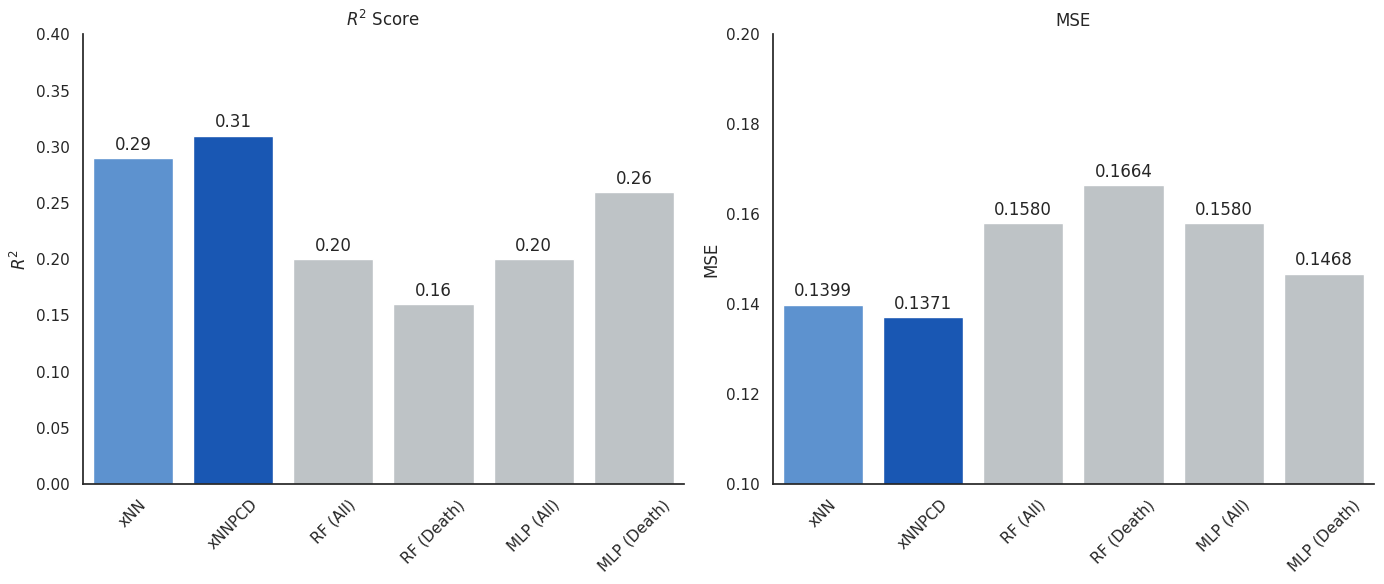

In [ ]:
sns.set(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: R2 Score
sns.barplot(
    data=df,
    x='Model',
    y='R2',
    palette=my_colors,
    ax=axes[0]
)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3, fontsize=12)
axes[0].set_title('$R^2$ Score')
axes[0].set_ylabel('$R^2$')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 0.4)
axes[0].tick_params(axis='x', rotation=45)

# Right panel: MSE
sns.barplot(
    data=df,
    x='Model',
    y='MSE',
    palette=my_colors,
    ax=axes[1]
)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3, fontsize=12)
axes[1].set_title('MSE')
axes[1].set_ylabel('MSE')
axes[1].set_xlabel('')
axes[1].set_ylim(0.1, 0.2)
axes[1].tick_params(axis='x', rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

We also visualize the regression performance by plotting predicted values against ground truth for both xNN and xNNPCD on the test set.

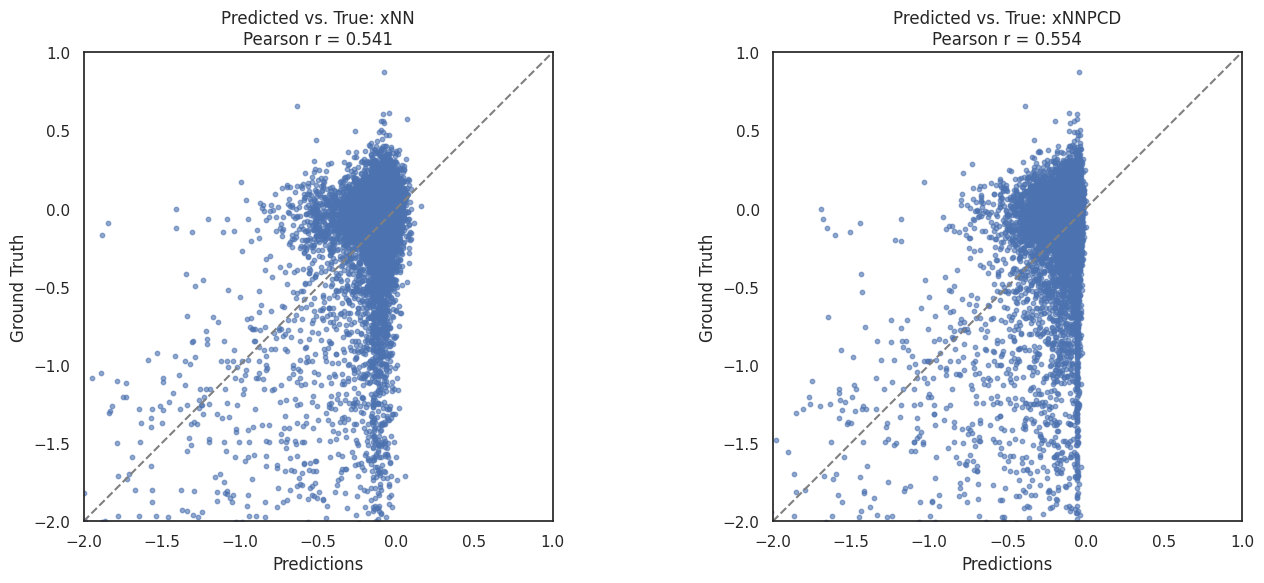

In [ ]:
# Prepare arrays for xNN
pred_np_xnn = test_preds_xnn.numpy().flatten()
true_np_xnn = test_labels_xnn.numpy().flatten()
r_xnn, _ = pearsonr(pred_np_xnn, true_np_xnn)

# Prepare arrays for xNNPCD
pred_np_xnnpcd = test_preds_xnnpcd.numpy().flatten()
true_np_xnnpcd = test_labels_xnnpcd.numpy().flatten()
r_xnnpcd, _ = pearsonr(pred_np_xnnpcd, true_np_xnnpcd)

min_val, max_val = -2, 1
ticks = np.arange(min_val, max_val + 0.1, 0.5)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: xNN
axes[0].scatter(pred_np_xnn, true_np_xnn, alpha=0.6, s=10)
axes[0].plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Ground Truth")
axes[0].set_title(f"Predicted vs. True: xNN\nPearson r = {r_xnn:.3f}")

# Right panel: xNNPCD
axes[1].scatter(pred_np_xnnpcd, true_np_xnnpcd, alpha=0.6, s=10)
axes[1].plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')
axes[1].set_xlim(min_val, max_val)
axes[1].set_ylim(min_val, max_val)
axes[1].set_xticks(ticks)
axes[1].set_yticks(ticks)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlabel("Predictions")
axes[1].set_ylabel("Ground Truth")
axes[1].set_title(f"Predicted vs. True: xNNPCD\nPearson r = {r_xnnpcd:.3f}")

plt.tight_layout()
plt.show()

## xNNPCD identifies novel negative regulators of PCD beyond prior annotations

In this section, we analyze the refined mask matrix to see how the model adjusted the gene-pathway weights during training. By comparing the learned weights of genes originally annotated in our prior knowledge against those that were not, we can assess if the model successfully prioritized known PCD genes. Furthermore, examining the top-weighted genes that lack prior annotation allows us to discover potential novel regulators of these cell death pathways.

In [ ]:
original_mask = pd.read_csv(base_dir + "/results/mask_original.csv", index_col=0)
new_mask = pd.read_csv(base_dir + "/results/mask_xNNPCD.csv", index_col=0)

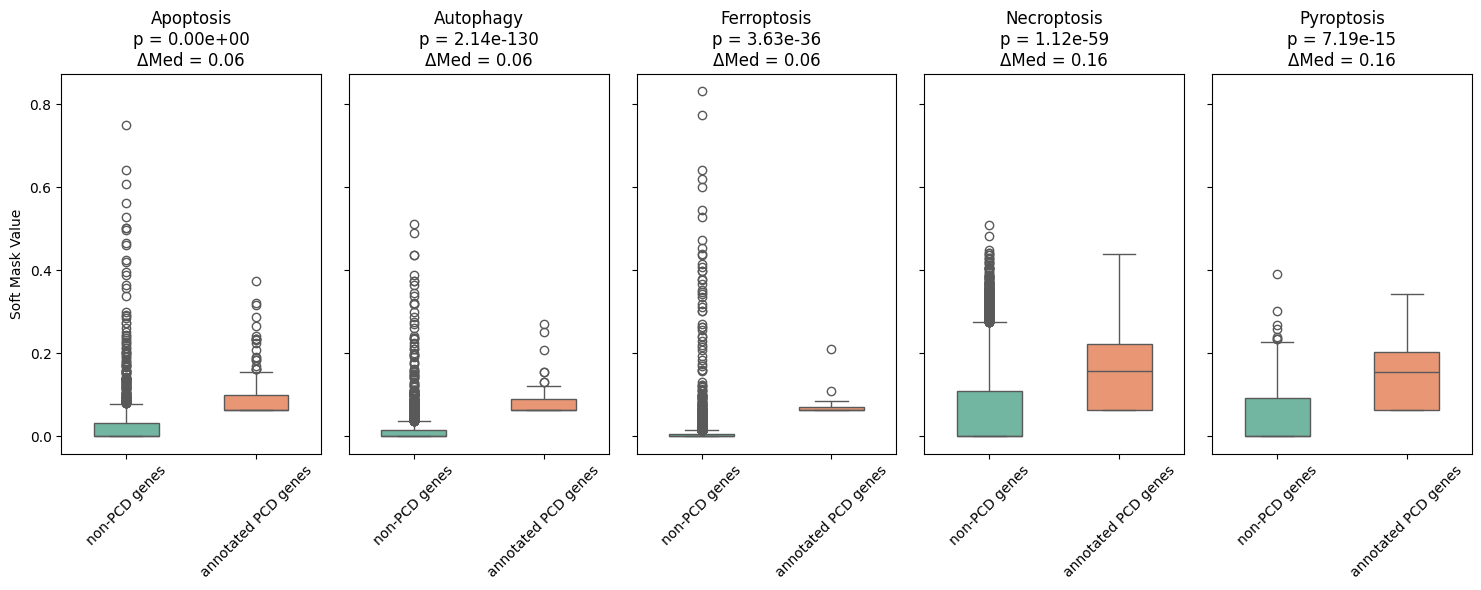

In [ ]:
# Initialize list to store statistical results for each pathway
pcd_mask_stats_list = []
pathways = [c for c in original_mask.columns if c != 'others']

fig, axes = plt.subplots(1, 5, figsize=(15, 6), sharey=True)

for ax, pathway in zip(axes, pathways):
    prior_mask_col = original_mask[pathway]
    refined_mask_col = new_mask[pathway]

    # Separate weights based on prior knowledge annotation
    weights_in_prior = refined_mask_col[prior_mask_col == 1].values
    weights_not_in_prior = refined_mask_col[prior_mask_col == 0].values

    # Perform Mann-Whitney U test
    stat, p_val = mannwhitneyu(weights_in_prior, weights_not_in_prior, alternative='greater')
    median_diff = np.median(weights_in_prior) - np.median(weights_not_in_prior)

    pcd_mask_stats_list.append({
        'Pathway': pathway,
        'P-value': p_val,
        'N (Not in Prior)': len(weights_not_in_prior),
        'N (In Prior)': len(weights_in_prior),
        'Median Diff': median_diff
    })

    # Prepare data for plotting
    pcd_mask_plot_data = pd.DataFrame({
        'Gene Type': np.concatenate([['non-PCD genes'] * len(weights_not_in_prior), ['annotated PCD genes'] * len(weights_in_prior)]),
        'Soft Mask Value': np.concatenate([weights_not_in_prior, weights_in_prior])
    })

    sns.boxplot(
        x='Gene Type',
        y='Soft Mask Value',
        hue='Gene Type',
        data=pcd_mask_plot_data,
        palette="Set2",
        width=0.5,
        showfliers=True,
        ax=ax,
        legend=False
    )

    p_text = f"p = {p_val:.2e}\n\u0394Med = {median_diff:.2f}"
    ax.set_title(f"{pathway.capitalize()}\n{p_text}", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    if ax == axes[0]:
        ax.set_ylabel("Soft Mask Value")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
top_n = 2

print(f"{'-'*45}\n{'Pathway':<15}| {'Novel Gene':<15} | {'Weight':<10}\n{'-'*45}")
for pathway in new_mask.columns[:5]:
    refined_pathway_weights = new_mask[pathway]

    # Filter out genes that are already in prior knowledge
    genes_not_in_prior = refined_pathway_weights[original_mask[pathway] == 0]

    # Get the top N novel genes
    top_genes = genes_not_in_prior.nlargest(top_n)

    for rank, (gene, weight) in enumerate(top_genes.items(), 1):
        print(f"{pathway.capitalize():<15}| {gene:<15} | {weight:.4f}")

---------------------------------------------
Pathway        | Novel Gene      | Weight    
---------------------------------------------
Apoptosis      | RPL23A          | 0.7500
Apoptosis      | RPL8            | 0.6409
Autophagy      | HSPA5           | 0.5113
Autophagy      | PSMA5           | 0.4899
Ferroptosis    | PSMA5           | 0.8313
Ferroptosis    | SNRPA1          | 0.7747
Necroptosis    | GLRA1           | 0.5093
Necroptosis    | SLC6A2          | 0.4819
Pyroptosis     | ASAH1           | 0.3903
Pyroptosis     | BRD1            | 0.3020


## Mask values identify PCD regulators while essentiality distinguishes negative from positive

### Positive and negative regulator query and mapping

In [ ]:
# Target pathways and GO IDs
pcd_pathways = {
    'apoptosis': {'neg': 'GO:0043066', 'pos': 'GO:0043065'},
    'autophagy': {'neg': 'GO:0010507', 'pos': 'GO:0010508'},
    'ferroptosis': {'neg': 'GO:0110076', 'pos': 'GO:0160020'},
    'necroptosis': {'neg': 'GO:0060546', 'pos': 'GO:0060545'},
    'pyroptosis': {'neg': 'GO:0160028', 'pos': 'GO:0140639'}
}

taxon_id = "9606"

In [ ]:
def fetch_genes_from_quickgo(go_id, taxon_id="9606"):
    """Fetch gene symbols for a specific GO ID from QuickGO API."""
    genes = set()
    url = "https://www.ebi.ac.uk/QuickGO/services/annotation/search"
    params = {
        "goId": go_id,
        "taxonId": taxon_id,
        "limit": 100,
        "page": 1
    }

    while True:
        response = requests.get(url, params=params, headers={"Accept": "application/json"})
        data = response.json()

        # Extract gene symbols from current page
        for result in data.get('results', []):
            if 'symbol' in result:
                genes.add(result['symbol'])

        # Check pagination
        page_info = data.get('pageInfo', {})
        if params['page'] >= page_info.get('total', 1):
            break

        params['page'] += 1
        time.sleep(0.1)  # Rate limiting

    return list(genes)

In [ ]:
pathway_genes = {}

# Loop through pathways and fetch genes
for pathway, directions in pcd_pathways.items():
    pathway_genes[pathway] = {}

    for direction, go_id in directions.items():
        genes = fetch_genes_from_quickgo(go_id)
        pathway_genes[pathway][direction] = genes

### Integration of functional annotations, dependency scores, and mask values

In [ ]:
# Define gene sets: 'death' genes within KO data and the remaining 'others'
gene_ko_death = list(set(gene_ko).intersection(set(gene_death)))
gene_ko_background = list(set(gene_ko) - set(gene_death))
df_death = pd.DataFrame({'gene': gene_ko_death, 'group': 'death'})
df_bg = pd.DataFrame({'gene': gene_ko_background, 'group': 'background'})

# Calculate mean dependency scores across samples for each gene
gene_dependency_means = sample_info.groupby('cmap_name')['dependency'].mean()

In [ ]:
# Initialize the master DataFrame
ko_info = pd.concat([df_death, df_bg], ignore_index=True)

# Map the global mean dependency scores
ko_info['dependency score'] = ko_info['gene'].map(gene_dependency_means)

# Classify gene regulatory roles (positive, negative, or both) for each pathway
for pathway, directions in pathway_genes.items():
    col_name = f"{pathway} type"
    pos_genes = set(directions.get('pos', []))
    neg_genes = set(directions.get('neg', []))

    # Identify if a gene exists in positive or negative gene sets
    is_pos = ko_info['gene'].isin(pos_genes)
    is_neg = ko_info['gene'].isin(neg_genes)

    # Apply logic to assign 'both', 'positive', or 'negative' labels
    conditions = [is_pos & is_neg, is_pos, is_neg]
    choices = ['both', 'positive', 'negative']
    ko_info[col_name] = np.select(conditions, choices, default=np.nan)

# Map individual pathway mask values from the 'new_mask' source to each gene
for p in pathway_genes.keys():
    col_name = f"{p} mask value"
    ko_info[col_name] = ko_info['gene'].map(new_mask[p])

# Final data cleanup: reset index and save to the results directory
ko_info = ko_info.sort_values(by='gene', ignore_index=True)
# ko_info.to_csv(base_dir + "/results/ko_info.csv")

### Comparative and correlation statistics

In [ ]:
# Load knockout dataset
ko_info = pd.read_csv(base_dir + "/results/ko_info.csv", index_col=0)

In [ ]:
ko_info

,gene,group,dependency score,apoptosis type,autophagy type,ferroptosis type,necroptosis type,pyroptosis type,apoptosis mask value,autophagy mask value,ferroptosis mask value,necroptosis mask value,pyroptosis mask value
0,A1CF,background,-0.040110,NaN,NaN,NaN,NaN,NaN,0.041361,0.019670,0.027789,0.132860,0.100344
1,A2M,background,0.028347,NaN,NaN,NaN,NaN,NaN,0.049798,0.084280,0.015488,0.192991,0.117954
2,AAK1,background,-0.162604,NaN,NaN,NaN,NaN,NaN,0.036974,0.028392,0.018279,0.171151,0.121019
3,AAMP,background,-1.248196,NaN,NaN,NaN,NaN,NaN,0.101145,0.016043,0.029773,0.023173,0.104937
4,AASS,background,0.024662,NaN,NaN,NaN,NaN,NaN,0.040653,0.030439,0.010560,0.170674,0.174344
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3962,ZNF646,background,-0.109439,NaN,NaN,NaN,NaN,NaN,0.030925,0.008131,0.002482,0.215643,0.076809
3963,ZNF668,background,-0.057006,NaN,NaN,NaN,NaN,NaN,0.050869,0.054618,0.055742,0.182546,0.057993
3964,ZNF80,background,-0.147454,NaN,NaN,NaN,NaN,NaN,0.043521,0.023187,0.009415,0.124949,0.124394
3965,ZPBP,background,0.238195,NaN,NaN,NaN,NaN,NaN,0.026576,0.030318,0.005087,0.148915,0.127329


In [ ]:
# Stratify data based on predefined death (target) and others (background) groups
target_df = ko_info[(ko_info['group'] == "death")]
background_df = ko_info[(ko_info['group'] == "background")]

In [ ]:
# Extract mask values for negatively and positively associated PCD types
mask_val_neg = np.concatenate([
    target_df.loc[(target_df['apoptosis type'] == "negative") & (target_df['apoptosis type'].notna()), 'apoptosis mask value'],
    target_df.loc[(target_df['autophagy type'] == "negative") & (target_df['autophagy type'].notna()), 'autophagy mask value'],
    target_df.loc[(target_df['ferroptosis type'] == "negative") & (target_df['ferroptosis type'].notna()), 'ferroptosis mask value'],
    target_df.loc[(target_df['necroptosis type'] == "negative") & (target_df['necroptosis type'].notna()), 'necroptosis mask value'],
    target_df.loc[(target_df['pyroptosis type'] == "negative") & (target_df['pyroptosis type'].notna()), 'pyroptosis mask value']
])

mask_val_pos = np.concatenate([
    target_df.loc[(target_df['apoptosis type'] == "positive") & (target_df['apoptosis type'].notna()), 'apoptosis mask value'],
    target_df.loc[(target_df['autophagy type'] == "positive") & (target_df['autophagy type'].notna()), 'autophagy mask value'],
    target_df.loc[(target_df['ferroptosis type'] == "positive") & (target_df['ferroptosis type'].notna()), 'ferroptosis mask value'],
    target_df.loc[(target_df['necroptosis type'] == "positive") & (target_df['necroptosis type'].notna()), 'necroptosis mask value'],
    target_df.loc[(target_df['pyroptosis type'] == "positive") & (target_df['pyroptosis type'].notna()), 'pyroptosis mask value']
])

# Extract dependency scores for negatively and positively associated PCD types
dep_score_neg = np.concatenate([
    target_df.loc[(target_df['apoptosis type'] == "negative") & (target_df['apoptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['autophagy type'] == "negative") & (target_df['autophagy type'].notna()), 'dependency score'],
    target_df.loc[(target_df['ferroptosis type'] == "negative") & (target_df['ferroptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['necroptosis type'] == "negative") & (target_df['necroptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['pyroptosis type'] == "negative") & (target_df['pyroptosis type'].notna()), 'dependency score']
])

dep_score_pos = np.concatenate([
    target_df.loc[(target_df['apoptosis type'] == "positive") & (target_df['apoptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['autophagy type'] == "positive") & (target_df['autophagy type'].notna()), 'dependency score'],
    target_df.loc[(target_df['ferroptosis type'] == "positive") & (target_df['ferroptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['necroptosis type'] == "positive") & (target_df['necroptosis type'].notna()), 'dependency score'],
    target_df.loc[(target_df['pyroptosis type'] == "positive") & (target_df['pyroptosis type'].notna()), 'dependency score']
])

# Extract background features (non-PCD) from background dataframe
mask_val_bg = np.concatenate([
    background_df['apoptosis mask value'],
    background_df['autophagy mask value'],
    background_df['ferroptosis mask value'],
    background_df['necroptosis mask value'],
    background_df['pyroptosis mask value']
])

dep_score_bg = np.concatenate([background_df['dependency score']] * 5) # Replicate dependency scores 5 times

# Extract pooled features for all PCD pathways
mask_val_all_pcd = np.concatenate([
    target_df['apoptosis mask value'],
    target_df['autophagy mask value'],
    target_df['ferroptosis mask value'],
    target_df['necroptosis mask value'],
    target_df['pyroptosis mask value']
])

dep_score_all_pcd = np.concatenate([target_df['dependency score']] * 5) # Replicate dependency scores 5 times

In [ ]:
# Perform Mann-Whitney U test
pval_mask_neg_vs_bg = mannwhitneyu(mask_val_neg, mask_val_bg, alternative='greater', method="asymptotic").pvalue
pval_mask_pos_vs_bg = mannwhitneyu(mask_val_pos, mask_val_bg, alternative='greater', method="asymptotic").pvalue
pval_mask_neg_vs_pos = mannwhitneyu(mask_val_neg, mask_val_pos, alternative='greater', method="asymptotic").pvalue

print("Mask Value Statistical Comparison:")
print(f"Negative PCD vs Background (Greater) : P-value = {pval_mask_neg_vs_bg:.4e}")
print(f"Positive PCD vs Background (Greater) : P-value = {pval_mask_pos_vs_bg:.4e}")
print(f"Negative PCD vs Positive PCD (Greater): P-value = {pval_mask_neg_vs_pos:.4e}")

Mask Value Statistical Comparison:
Negative PCD vs Background (Greater) : P-value = 5.3636e-09
Positive PCD vs Background (Greater) : P-value = 8.4887e-07
Negative PCD vs Positive PCD (Greater): P-value = 5.8934e-03


In [ ]:
# Generate binary indicators: 1 if any of the 5 pathways is negative/positive, else 0
indicator_neg_mask = (
    ((target_df['apoptosis type'] == "negative") & (target_df['apoptosis type'].notna())) |
    ((target_df['autophagy type'] == "negative") & (target_df['autophagy type'].notna())) |
    ((target_df['ferroptosis type'] == "negative") & (target_df['ferroptosis type'].notna())) |
    ((target_df['necroptosis type'] == "negative") & (target_df['necroptosis type'].notna())) |
    ((target_df['pyroptosis type'] == "negative") & (target_df['pyroptosis type'].notna()))
)
indicator_neg = indicator_neg_mask.astype(int)

indicator_pos_mask = (
    ((target_df['apoptosis type'] == "positive") & (target_df['apoptosis type'].notna())) |
    ((target_df['autophagy type'] == "positive") & (target_df['autophagy type'].notna())) |
    ((target_df['ferroptosis type'] == "positive") & (target_df['ferroptosis type'].notna())) |
    ((target_df['necroptosis type'] == "positive") & (target_df['necroptosis type'].notna())) |
    ((target_df['pyroptosis type'] == "positive") & (target_df['pyroptosis type'].notna()))
)
indicator_pos = indicator_pos_mask.astype(int)

In [ ]:
# Perform Mann-Whitney U test on Dependency Scores based on the generated indicators
pval_dep_neg_vs_pos = mannwhitneyu(
    target_df.loc[indicator_neg == 1, 'dependency score'],
    target_df.loc[indicator_pos == 1, 'dependency score'],
    alternative='less', method="asymptotic"
).pvalue

pval_dep_neg_vs_bg = mannwhitneyu(
    target_df.loc[indicator_neg == 1, 'dependency score'],
    background_df['dependency score'],
    alternative='less', method="asymptotic"
).pvalue

pval_dep_other_vs_bg = mannwhitneyu(
    target_df.loc[indicator_neg == 0, 'dependency score'],
    background_df['dependency score'],
    alternative='two-sided', method="asymptotic"
).pvalue

print("Dependency Score Statistical Comparison:")
print(f"Negative vs Positive PCD (Less)     : P-value = {pval_dep_neg_vs_pos:.4e}")
print(f"Negative PCD vs Background (Less)   : P-value = {pval_dep_neg_vs_bg:.4e}")
print(f"Other PCD vs Background (Two-sided) : P-value = {pval_dep_other_vs_bg:.4e}")

Dependency Score Statistical Comparison:
Negative vs Positive PCD (Less)     : P-value = 3.0507e-03
Negative PCD vs Background (Less)   : P-value = 4.2997e-02
Other PCD vs Background (Two-sided) : P-value = 6.4023e-01


In [ ]:
# Pearson correlation between Mask Values and Dependency Scores
cor_pcd, pval_cor_pcd = pearsonr(mask_val_all_pcd, dep_score_all_pcd)
cor_bg, pval_cor_bg = pearsonr(mask_val_bg, dep_score_bg)

print("Pearson Correlation Analysis:")
print(f"Pooled PCD Data : Correlation = {cor_pcd:.4f} (P-value = {pval_cor_pcd:.4e})")
print(f"Background Data : Correlation = {cor_bg:.4f} (P-value = {pval_cor_bg:.4e})")

Pearson Correlation Analysis:
Pooled PCD Data : Correlation = -0.2173 (P-value = 1.2969e-25)
Background Data : Correlation = -0.0958 (P-value = 3.9967e-37)


/tmp/SLURM_3404715/ipykernel_89598/994304722.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Mask Value', data=plot1_data,
/tmp/SLURM_3404715/ipykernel_89598/994304722.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Dependency Score', data=plot2_data,


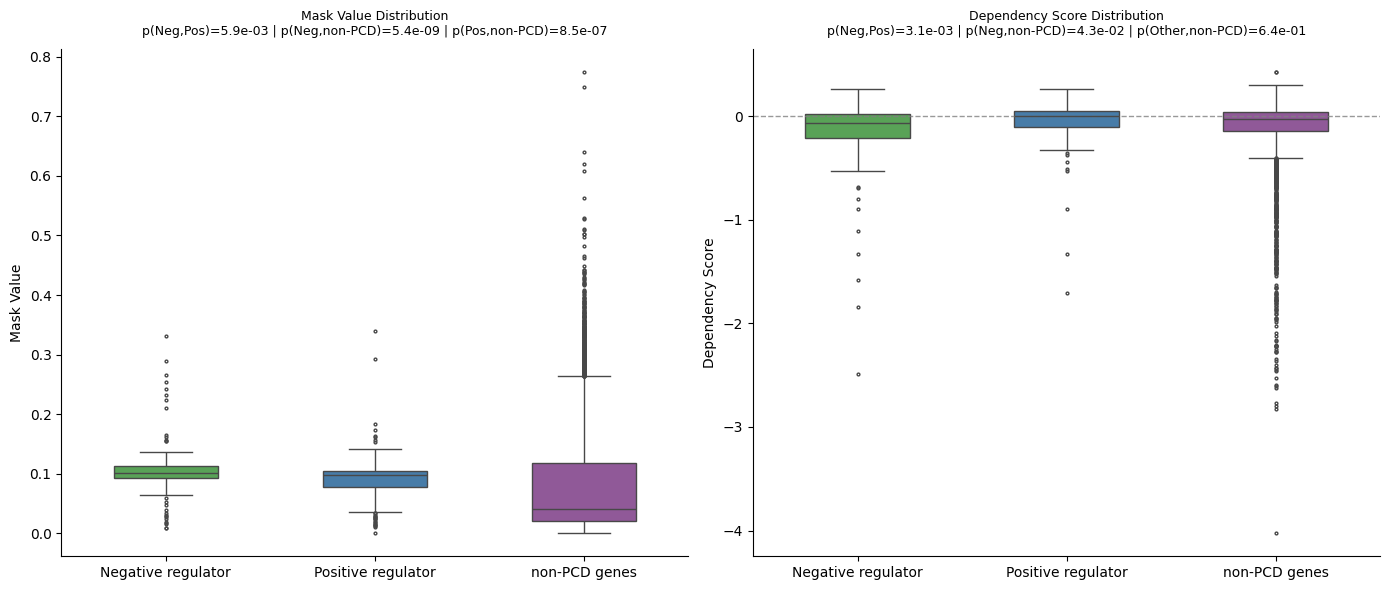

In [ ]:
# Define uniform group names for the X-axis
name_neg = 'Negative regulator'
name_pos = 'Positive regulator'
name_non = 'non-PCD genes'

# Prepare data for plotting
plot1_data = pd.DataFrame({
    'Mask Value': np.concatenate([mask_val_neg, mask_val_pos, mask_val_bg]),
    'Group': ([name_neg] * len(mask_val_neg) +
              [name_pos] * len(mask_val_pos) +
              [name_non] * len(mask_val_bg))
})

dep_neg = target_df.loc[indicator_neg == 1, 'dependency score'].values
dep_pos = target_df.loc[indicator_pos == 1, 'dependency score'].values
dep_bg = background_df['dependency score'].values

plot2_data = pd.DataFrame({
    'Dependency Score': np.concatenate([dep_neg, dep_pos, dep_bg]),
    'Group': ([name_neg] * len(dep_neg) +
              [name_pos] * len(dep_pos) +
              [name_non] * len(dep_bg))
})

# Define color palette (Green, Blue, Purple)
my_palette = {
    name_neg: '#4daf4a',
    name_pos: '#377eb8',
    name_non: '#984ea3'
}

# Initialize subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Left panel: Mask Value Distribution
sns.boxplot(x='Group', y='Mask Value', data=plot1_data,
            palette=my_palette, width=0.5, fliersize=2, ax=axes[0])
title1 = (
    "Mask Value Distribution\n"
    f"p(Neg,Pos)={pval_mask_neg_vs_pos:.1e} | p(Neg,non-PCD)={pval_mask_neg_vs_bg:.1e} | p(Pos,non-PCD)={pval_mask_pos_vs_bg:.1e}"
)
axes[0].set_title(title1, fontsize=9, pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Mask Value')

# Right Panel: Dependency Score Distribution
sns.boxplot(x='Group', y='Dependency Score', data=plot2_data,
            palette=my_palette, width=0.5, fliersize=2, ax=axes[1])
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8)
title2 = (
    "Dependency Score Distribution\n"
    f"p(Neg,Pos)={pval_dep_neg_vs_pos:.1e} | p(Neg,non-PCD)={pval_dep_neg_vs_bg:.1e} | p(Other,non-PCD)={pval_dep_other_vs_bg:.1e}"
)
axes[1].set_title(title2, fontsize=9, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Dependency Score')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# # Prepare paired 2D data
# plot_kde_data = pd.DataFrame({
#     'Mask Value': np.concatenate([mask_val_neg, mask_val_pos, mask_val_bg]),
#     'Dependency Score': np.concatenate([dep_score_neg, dep_score_pos, dep_score_bg]),
#     'Group': (
#         ['Negative regulator'] * len(mask_val_neg) +
#         ['Positive regulator'] * len(mask_val_pos) +
#         ['non-PCD genes'] * len(mask_val_bg)
#     )
# })

# # Define color palette
# my_palette = {
#     'Negative regulator': '#4daf4a',
#     'Positive regulator': '#377eb8',
#     'non-PCD genes': '#984ea3'
# }

# # Initialize a 1x3 FacetGrid
# g = sns.FacetGrid(
#     plot_kde_data,
#     col="Group",
#     hue="Group",
#     palette=my_palette,
#     height=5,
#     aspect=1
# )

# # Map filled 2D KDE plots to each subplot
# g.map_dataframe(
#     sns.kdeplot,
#     x='Mask Value',
#     y='Dependency Score',
#     fill=True,
#     levels=8,
#     alpha=0.6,
#     warn_singular=False
# )

# g.set_axis_labels("Mask Value", "Dependency Score")
# g.set_titles(col_template="{col_name}", size=12, pad=10)
# g.set(xlim=(-0.05, 0.4), ylim=(-3, 1))

# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 6))

# # Plot background (non-PCD) as thin, semi-transparent base layers
# sns.kdeplot(
#     data=plot_kde_data[plot_kde_data['Group'] == 'non-PCD genes'],
#     x='Mask Value',
#     y='Dependency Score',
#     color='#984ea3',
#     alpha=0.3,
#     fill=False,
#     levels=6,
#     linewidths=1,
#     warn_singular=False
# )

# # Plot target regulators with thick, prominent contour lines
# target_data = plot_kde_data[plot_kde_data['Group'].isin(['Positive regulator', 'Negative regulator'])]
# sns.kdeplot(
#     data=target_data,
#     x='Mask Value',
#     y='Dependency Score',
#     hue='Group',
#     palette={'Negative regulator': '#4daf4a', 'Positive regulator': '#377eb8'},
#     common_norm=False,
#     fill=False,
#     levels=5,
#     linewidths=2,
#     alpha=0.9,
#     warn_singular=False,
#     legend=False
# )

# # Create a custom legend
# custom_lines = [
#     Line2D([0], [0], color='#4daf4a', lw=2),
#     Line2D([0], [0], color='#377eb8', lw=2),
#     Line2D([0], [0], color='#984ea3', lw=1, alpha=0.6)
# ]
# plt.legend(
#     custom_lines,
#     ['Negative regulator', 'Positive regulator', 'non-PCD genes'],
#     title="Group",
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     frameon=False
# )

# plt.xlim(-0.05, 0.4)
# plt.ylim(-3, 1)

# plt.title("2D Density: PCD Regulators vs Background", fontsize=14, pad=15)
# plt.xlabel("Mask Value")
# plt.ylabel("Dependency Score")

# sns.despine()
# plt.tight_layout()
# plt.show()

### Individual pathway level dependency comparison

/tmp/SLURM_3404715/ipykernel_89598/2751559702.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mask Group', y='Dependency Score', data=plot_data,
/tmp/SLURM_3404715/ipykernel_89598/2751559702.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mask Group', y='Dependency Score', data=plot_data,
/tmp/SLURM_3404715/ipykernel_89598/2751559702.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mask Group', y='Dependency Score', data=plot_data,
/tmp/SLURM_3404715/ipykernel_89598/2751559702.py:41: FutureWarning: 

Passing `palette` 

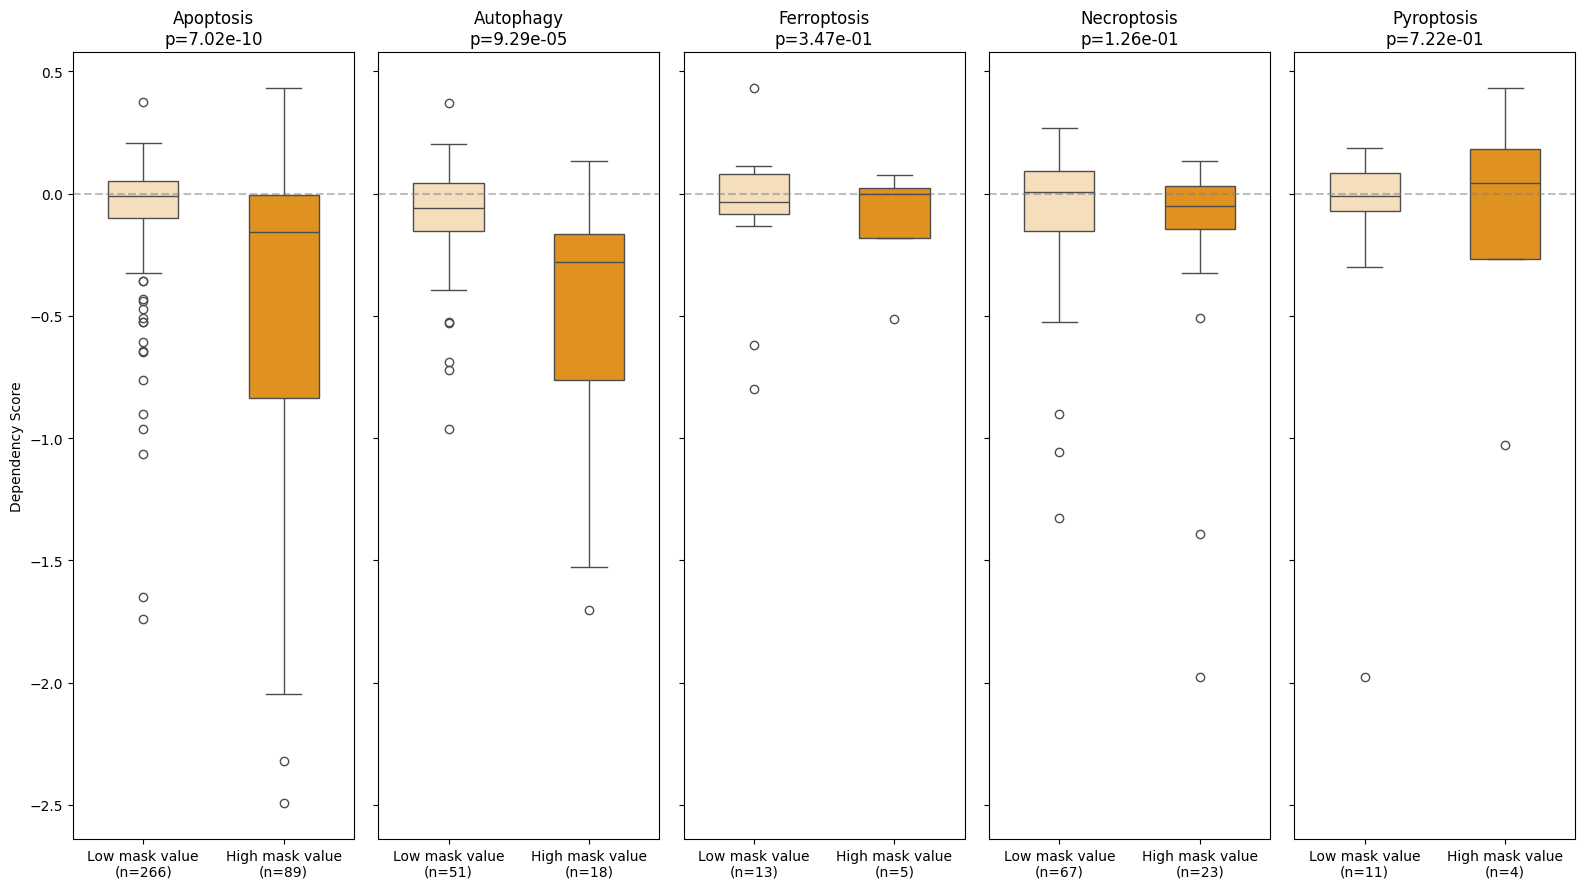

In [ ]:
# Filter for the overarching 'death' gene group
death_genes_df = ko_info[ko_info['group'] == 'death']

# Plot initialization
fig, axes = plt.subplots(1, 5, figsize=(16, 9), sharey=True)
custom_palette = ['#FFE0B2', '#FF9800']

for i, pathway in enumerate(pathways):
    ax = axes[i]

    # Extract all genes associated with the current pathway
    current_pathway_genes = set(gene_pcd[gene_pcd['Pathway name'] == pathway]['Gene name'])

    # Subset death genes that belong to this specific pathway
    valid_df = death_genes_df[death_genes_df['gene'].isin(current_pathway_genes)].copy()

    # Calculate the 75th percentile cutoff for mask values
    mask_vals = valid_df[f'{pathway} mask value']
    cutoff_val = mask_vals.quantile(0.75)

    # Stratify genes into high/low mask value groups
    high_mask = mask_vals >= cutoff_val
    low_mask = mask_vals < cutoff_val
    scores_high = valid_df.loc[high_mask, 'dependency score'].values
    scores_low = valid_df.loc[low_mask, 'dependency score'].values

    # Perform Mann-Whitney U test
    stat, p_val = mannwhitneyu(scores_high, scores_low, alternative='less', method='asymptotic')

    # Create dynamic x-axis labels with sample sizes
    label_low = f"Low mask value\n(n={len(scores_low)})"
    label_high = f"High mask value\n(n={len(scores_high)})"

    # Prepare data for the current subplot
    plot_data = pd.DataFrame({
        'Mask Group': [label_low] * len(scores_low) + [label_high] * len(scores_high),
        'Dependency Score': np.concatenate([scores_low, scores_high])
    })

    # Generate boxplot without outliers
    sns.boxplot(x='Mask Group', y='Dependency Score', data=plot_data,
                palette=custom_palette, width=0.5, ax=ax)

    # Format subplot title and add baseline reference
    ax.set_title(f"{pathway.capitalize()}\np={p_val:.2e}", fontsize=12)
    ax.set_xlabel("")
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)

    # Keep Y-axis label only on the leftmost plot
    if i == 0:
        ax.set_ylabel("Dependency Score")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

### t-SNE

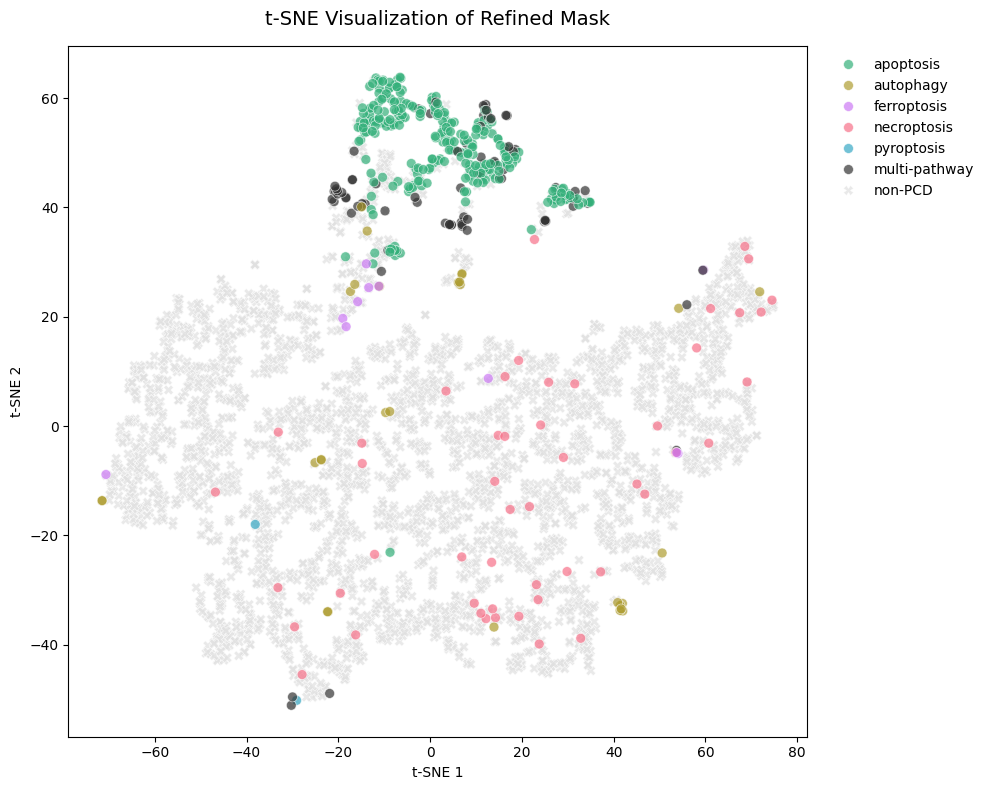

In [ ]:
# Map genes to their specific pathway or label multi-pathway genes
pcd_groups = gene_pcd.groupby('Gene name')['Pathway name'].unique()
gene_pathway_map = {}
for gene, pathways in pcd_groups.items():
    if len(pathways) > 1:
        gene_pathway_map[gene] = 'multi-pathway'
    else:
        gene_pathway_map[gene] = pathways[0]

# Extract feature matrix directly using the genes from ko_info
genes_ordered = ko_info['gene'].tolist()
X = new_mask.iloc[:, 0:5].loc[genes_ordered].values

# Assign proper labels for visualization
labels = []
for _, row in ko_info.iterrows():
    g = row['gene']
    if row['group'] == 'background':
        labels.append('non-PCD')
    else:
        labels.append(gene_pathway_map.get(g))

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, learning_rate='auto', perplexity=30)
X_embedded = tsne.fit_transform(X)

plot_df = pd.DataFrame({
    't-SNE 1': X_embedded[:, 0],
    't-SNE 2': X_embedded[:, 1],
    'Category': labels
})

# Sort dataframe to ensure 'non-PCD' genes are plotted as the bottom layer
plot_df['is_bg'] = plot_df['Category'] == 'non-PCD'
plot_df = plot_df.sort_values(by='is_bg', ascending=False).drop(columns='is_bg')

# Configure specific colors for background and distinct pathways
unique_categories = plot_df['Category'].unique()
custom_palette = {}
if 'non-PCD' in unique_categories:
    custom_palette['non-PCD'] = '#E0E0E0'
if 'multi-pathway' in unique_categories:
    custom_palette['multi-pathway'] = '#333333'
remaining_cats = [c for c in unique_categories if c not in custom_palette]
pcd_colors = sns.color_palette("husl", len(remaining_cats))
for cat, color in zip(remaining_cats, pcd_colors):
    custom_palette[cat] = color

# Order the pathways in legend
pcd_cats_sorted = sorted([c for c in unique_categories if c not in ['multi-pathway', 'non-PCD']])
legend_order = pcd_cats_sorted + [c for c in ['multi-pathway', 'non-PCD'] if c in unique_categories]

# Generate the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='t-SNE 1',
    y='t-SNE 2',
    hue='Category',
    hue_order=legend_order,
    palette=custom_palette,
    style='Category',
    markers={cat: ('X' if cat == 'non-PCD' else 'o') for cat in unique_categories},
    alpha=0.7,
    s=50,
    edgecolor='w',
    linewidth=0.5
)

# Format plot aesthetics
plt.title("t-SNE Visualization of Refined Mask", fontsize=14, pad=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
# plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Transfer learning enables pathway-specific drug screening

### Data loading and splitting

#### Raw processing

In [ ]:
# Read GCTX expression profile data
gct_data = parse(base_dir + "/data/level5_beta_trt_cp_n720216x12328.gctx")
data_matrix_drug = gct_data.data_df.T
row_metadata = gct_data.row_metadata_df
col_metadata = gct_data.col_metadata_df

/home1/yinq/.local/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/home1/yinq/.local/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


In [ ]:
# Read and process L1000 sample metadata
sig_info = pd.read_table(base_dir + "/data/siginfo_beta.txt")
index_df = pd.DataFrame(data_matrix_drug.index)
index_df.columns = ['sig_id']

# Match matrix index with sample info
sample_info_drug = index_df.merge(sig_info, on='sig_id', how='left')
sample_info_drug.set_index('sig_id', inplace=True)

# Filter for compound treatment group (trt_cp)
compound_sigs_df = sample_info_drug[sample_info_drug['pert_type'] == 'trt_cp'].copy()

# Sort and drop duplicates to keep the highest dose / longest time per cell line and drug
sorted_sigs_df = compound_sigs_df.sort_values(
    by=['cell_iname', 'cmap_name', 'pert_time', 'pert_dose'],
    ascending=[True, True, False, False]
)
unique_sigs_df = sorted_sigs_df.drop_duplicates(
    subset=['cell_iname', 'cmap_name'],
    keep='first'
)
sample_info_drug = unique_sigs_df[['cell_iname', 'cmap_name', 'pert_dose', 'pert_dose_unit', 'pert_time', 'pert_time_unit']]

/tmp/SLURM_3341118/ipykernel_2198732/4035384149.py:2: DtypeWarning: Columns (0,3,4,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  sig_info = pd.read_table(base_dir + "/data/siginfo_beta.txt")


In [ ]:
# Read CTRP drug sensitivity datasets
auc_curves_df = pd.read_csv(base_dir + '/data/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.data.curves_post_qc.txt', sep='\t')
exp_metadata_df = pd.read_csv(base_dir + '/data/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_experiment.txt', sep='\t')
cell_metadata_df = pd.read_csv(base_dir + '/data/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_cell_line.txt', sep='\t')
compound_metadata_df = pd.read_csv(base_dir + '/data/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_compound.txt', sep='\t')

In [ ]:
# Merge CTRP experiment, cell line, and compound info
ctrp_merged_df = pd.merge(
    auc_curves_df[['experiment_id', 'master_cpd_id', 'area_under_curve']],
    exp_metadata_df[['experiment_id', 'master_ccl_id']],
    on='experiment_id',
    how='left'
)

ctrp_merged_df = pd.merge(
    ctrp_merged_df,
    cell_metadata_df[['master_ccl_id', 'ccl_name']],
    on='master_ccl_id',
    how='left'
)

ctrp_merged_df = pd.merge(
    ctrp_merged_df,
    compound_metadata_df[['master_cpd_id', 'cpd_name']],
    on='master_cpd_id',
    how='left'
)

In [ ]:
# Calculate normalized AUC (relative to the maximum AUC per drug)
max_auc_per_drug = ctrp_merged_df.groupby('master_cpd_id')['area_under_curve'].transform('max')
ctrp_merged_df['auc_normalized'] = ctrp_merged_df['area_under_curve'] / max_auc_per_drug

In [ ]:
# Extract final required columns and calculate mean for identical conditions
ctrp_final_auc_df = ctrp_merged_df[['ccl_name', 'cpd_name', 'auc_normalized']].copy()
ctrp_final_auc_df.dropna(inplace=True)
ctrp_final_auc_df = ctrp_final_auc_df.groupby(['ccl_name', 'cpd_name'], as_index=False).mean()

In [ ]:
# Standardize cell and drug names for merging
sample_info_join_drug = sample_info_drug.reset_index()
sample_info_join_drug['join_cell'] = sample_info_join_drug['cell_iname'].apply(lambda x: str(x).lower().strip() if pd.notna(x) else "")
sample_info_join_drug['join_drug'] = sample_info_join_drug['cmap_name'].apply(lambda x: str(x).lower().strip() if pd.notna(x) else "")

ctrp_auc_join_df = ctrp_final_auc_df.copy()
ctrp_auc_join_df['join_cell'] = ctrp_auc_join_df['ccl_name'].apply(lambda x: str(x).lower().strip() if pd.notna(x) else "")
ctrp_auc_join_df['join_drug'] = ctrp_auc_join_df['cpd_name'].apply(lambda x: str(x).lower().strip() if pd.notna(x) else "")

In [ ]:
# Merge L1000 sample metadata with CTRP AUC data and format the final sample info
matched_drug_response_df = pd.merge(
    sample_info_join_drug,
    ctrp_auc_join_df,
    on=['join_cell', 'join_drug'],
    how='inner'
)

# Extract required columns and set 'sig_id' as the index
sample_info_drug = matched_drug_response_df[[
    'sig_id', 'cell_iname', 'cmap_name', 'auc_normalized', 'pert_dose', 'pert_time'
]].set_index('sig_id')

# Align the expression data matrix with the successfully matched samples
data_matrix_drug = data_matrix_drug.loc[sample_info_drug.index]

In [ ]:
# Map Entrez gene IDs to HGNC symbols using mygene
mg = mygene.MyGeneInfo()
gene_ids = list(data_matrix_drug.columns)
gene_info = mg.querymany(gene_ids, scopes="entrezgene", fields="symbol", species="human")

# Handle specific hardcoded gene ID exceptions
gene_names = [
    "UPK3B" if result["query"] == "80761" else
    "TMEM257" if result["query"] == "9142" else
    "OCLM" if result["query"] == "10896" else
    "KIAA1107" if result["query"] == "23285" else
    "LOC100507424" if result["query"] == "100507424" else
    "DGCR9" if result["query"] == "25787" else
    "LINC00341" if result["query"] == "79686" else
    "C10orf12" if result["query"] == "26148" else
    "CTAGE5" if result["query"] == "117153" else
    result.get("symbol", "Not found")
    for result in gene_info
]

# Assign the mapped gene names to the expression matrix columns and save
data_matrix_drug.columns = gene_names

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
9 input query terms found no hit:	['100507424', '10896', '117153', '23285', '25787', '26148', '79686', '80761', '9142']


In [ ]:
# data_matrix_drug.to_parquet("../data/data_matrix_drug.parquet", engine='pyarrow', compression='snappy')
# sample_info_drug.to_csv("../data/sample_info_drug.csv")

#### Directly load

In [ ]:
data_matrix_drug = pd.read_parquet(base_dir + "/data/data_matrix_drug.parquet", engine='pyarrow')
sample_info_drug = pd.read_csv(base_dir + "/data/sample_info_drug.csv", index_col=0)

In [ ]:
data_matrix_drug

,NAT2,ADA,CDH2,AKT3,MED6,NAALAD2,NAALADL1,ACOT8,ABI1,GNPDA1,...,REC8,HNRNPDL,DMTF1,PPP4R1,CDH1,SLC12A6,PTBP3,KCNE2,DGCR2,SCO2
sig_id,,,,,,,,,,,,,,,,,,,,,
ASG002_22RV1_24H:H19,0.3563,0.0924,0.1552,1.4333,-0.8584,0.9600,-0.2661,-0.3866,-0.0588,-0.0242,...,-0.2817,-3.5367,0.4844,-1.2916,0.5572,2.4200,-0.4384,1.9343,-0.8119,0.0790
ASG002_22RV1_24H:I16,-1.3187,-0.4632,-0.1623,-0.9944,-1.1148,-1.0250,-0.7322,-0.0970,-0.0750,-0.3544,...,-1.0738,1.8844,-0.0405,1.4584,0.5610,-0.7392,-0.1371,-1.1206,0.3229,-0.6943
ASG002_22RV1_24H:H01,0.0569,0.0379,-0.8272,-0.4517,0.3212,0.9659,-0.0722,-1.0793,2.6606,2.4613,...,-0.0418,0.4045,2.9862,-2.5496,0.9090,2.2422,0.8768,0.6323,1.2634,-2.6789
ASG002_22RV1_24H:L07,0.4647,-0.2810,-0.3448,0.4410,0.4529,-0.5849,-0.9332,-0.8203,1.3144,-1.9475,...,-0.1649,-0.8425,1.4925,0.6479,-1.4258,2.5132,1.4970,-0.5372,1.0772,-1.4353
ASG002_22RV1_24H:L01,1.9312,0.7504,-2.8290,2.6376,1.5148,2.1971,0.8040,-0.4788,0.6017,-0.2521,...,2.1113,-0.8025,4.2387,-1.0323,0.4066,2.3061,1.2402,3.5357,4.1843,2.3140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ASG002_ZR751_24H:G16,0.3385,0.1537,0.2660,0.6604,-1.2836,0.5465,1.4281,0.8710,-0.2106,0.7133,...,-0.4688,-0.8827,0.2542,-0.8407,1.1684,0.6770,-0.8558,0.3815,0.0038,1.2013
ASG002_ZR751_24H:P04,-1.1119,0.9674,0.5893,-1.2141,-0.9671,-0.7485,0.5113,1.7988,-1.6504,-1.1683,...,0.1094,1.0992,0.8560,0.4041,-0.4354,1.3684,1.6190,-0.1532,0.3147,0.7602
ASG002_ZR751_24H:F22,1.4525,2.0337,-0.9392,0.5074,-0.7997,-1.6275,0.3159,-2.3285,1.6788,0.0000,...,0.4204,-1.2816,0.1820,-0.0050,0.3734,0.0022,-1.2638,-0.1656,-0.8757,-0.0022


In [ ]:
sample_info_drug

,cell_iname,cmap_name,auc_normalized,pert_dose,pert_time
sig_id,,,,,
ASG002_22RV1_24H:H19,22RV1,ABT-737,0.646537,10.00000,24.0
ASG002_22RV1_24H:I16,22RV1,AM-580,0.788199,10.00000,24.0
ASG002_22RV1_24H:H01,22RV1,BI-2536,0.474164,10.00000,24.0
ASG002_22RV1_24H:L07,22RV1,KU-0063794,0.496044,10.00000,24.0
ASG002_22RV1_24H:L01,22RV1,PHA-793887,0.592804,10.00000,24.0
...,...,...,...,...,...
ASG002_ZR751_24H:G16,ZR751,tandutinib,0.851227,9.99995,24.0
ASG002_ZR751_24H:P04,ZR751,temozolomide,0.837085,10.00000,24.0
ASG002_ZR751_24H:F22,ZR751,trifluoperazine,0.858026,12.27010,24.0


In [ ]:
# Split data into train, validation, and test sets (80-10-10 split)
X_train_drug, X_temp_drug, y_train_drug, y_temp_drug = train_test_split(data_matrix_drug, sample_info_drug['auc_normalized'], test_size=0.2, random_state=RANDOM_SEED)
X_val_drug, X_test_drug, y_val_drug, y_test_drug = train_test_split(X_temp_drug, y_temp_drug, test_size=0.5, random_state=RANDOM_SEED)
X_train_final_drug = pd.concat([X_train_drug, X_val_drug])
y_train_final_drug = pd.concat([y_train_drug, y_val_drug])

In [ ]:
y_train_drug = pd.to_numeric(y_train_drug, errors='coerce')
y_val_drug = pd.to_numeric(y_val_drug, errors='coerce')
y_train_final_drug = pd.to_numeric(y_train_final_drug, errors='coerce')
y_test_drug = pd.to_numeric(y_test_drug, errors='coerce')

In [ ]:
# Load the mask matrix derived from xNNPCD
mask = pd.read_csv(base_dir + "/results/mask_xNNPCD.csv", index_col=0)

### Hyperparameter tuning

Similar as xNNPCD, we perform a grid search over learning rates, weight decays, and batch sizes to find the optimal configuration using early stopping on the validation set. In this stage, the mask matrix is fixed to the one derived from xNNPCD. We reuse the `MaskedMLP_Regression` class and datasets defined earlier to maintain consistency.

In [ ]:
# Define hyperparameter search grid
learning_rates = [1e-2, 1e-3, 1e-4]
weight_decays = [0, 1e-5, 1e-4, 1e-3]
batch_sizes = [128, 256, 512]
early_stopping_patience = 10

In [ ]:
# Prepare PyTorch tensors and datasets
X_train_tensor_drug = torch.tensor(X_train_drug.to_numpy(), dtype=torch.float32)
y_train_tensor_drug = torch.tensor(y_train_drug.to_numpy(), dtype=torch.float32).unsqueeze(1)
X_val_tensor_drug = torch.tensor(X_val_drug.to_numpy(), dtype=torch.float32)
y_val_tensor_drug = torch.tensor(y_val_drug.to_numpy(), dtype=torch.float32).unsqueeze(1)

train_dataset_drug = TensorDataset(X_train_tensor_drug, y_train_tensor_drug)
val_dataset_drug = TensorDataset(X_val_tensor_drug, y_val_tensor_drug)

In [ ]:
# Define training and validation logic
def train_and_validate_regression_drug(lr, weight_decay, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    g = torch.Generator().manual_seed(RANDOM_SEED)

    train_loader_drug = torch.utils.data.DataLoader(train_dataset_drug, batch_size=batch_size, shuffle=True, generator=g)
    val_loader_drug = torch.utils.data.DataLoader(val_dataset_drug, batch_size=batch_size)

    # Initialize model and load pretrained weights
    model_drug = MaskedMLP_Regression(gene_number=X_train_drug.shape[1], mask=mask).to(device)
    model_drug.load_state_dict(torch.load(base_dir + "/models/xNNPCD.pth", map_location=device))

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_drug.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_loss_drug = float('inf')
    epochs_no_improve = 0

    for epoch in range(200):
        # Training phase
        model_drug.train()
        for X_batch, y_batch in train_loader_drug:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output, _ = model_drug(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

        # Validation phase
        model_drug.eval()
        val_loss_drug = 0
        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader_drug:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                output, _ = model_drug(X_val_batch)
                val_loss_drug += criterion(output, y_val_batch).item() * X_val_batch.size(0)

        avg_val_loss_drug = val_loss_drug / len(val_loader_drug.dataset)
        print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss_drug:.4f}")
        scheduler.step()

        # Early stopping logic
        if avg_val_loss_drug < best_val_loss_drug:
            best_val_loss_drug = avg_val_loss_drug
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    return best_val_loss_drug

In [ ]:
# Execute grid search
best_params_drug = {}
best_overall_val_loss_drug = float('inf')

for lr in learning_rates:
    for wd in weight_decays:
        for bs in batch_sizes:
            print(f"--- Testing params for drug: lr={lr}, wd={wd}, bs={bs} ---")
            set_random_seed(RANDOM_SEED)

            current_val_loss = train_and_validate_regression_drug(lr, wd, bs)
            if current_val_loss < best_overall_val_loss_drug:
                best_overall_val_loss_drug = current_val_loss
                best_params_drug = {'lr': lr, 'weight_decay': wd, 'batch_size': bs}
                print(f"*** New OVERALL best params for drug found: {best_params_drug} with val_loss: {best_overall_val_loss_drug:.4f} ***\n")

print(f"Grid search finished. The best hyperparameters for drug are: {best_params_drug}")

--- Testing params for drug: lr=0.01, wd=0, bs=128 ---
Epoch 1 | Val Loss: 0.1166
Epoch 2 | Val Loss: 0.0457
Epoch 3 | Val Loss: 0.0287
Epoch 4 | Val Loss: 0.0220
Epoch 5 | Val Loss: 0.0189
Epoch 6 | Val Loss: 0.0174
Epoch 7 | Val Loss: 0.0171
Epoch 8 | Val Loss: 0.0163
Epoch 9 | Val Loss: 0.0158
Epoch 10 | Val Loss: 0.0156
Epoch 11 | Val Loss: 0.0152
Epoch 12 | Val Loss: 0.0151
Epoch 13 | Val Loss: 0.0151
Epoch 14 | Val Loss: 0.0149
Epoch 15 | Val Loss: 0.0147
Epoch 16 | Val Loss: 0.0147
Epoch 17 | Val Loss: 0.0148
Epoch 18 | Val Loss: 0.0148
Epoch 19 | Val Loss: 0.0148
Epoch 20 | Val Loss: 0.0147
Epoch 21 | Val Loss: 0.0147
Epoch 22 | Val Loss: 0.0148
Epoch 23 | Val Loss: 0.0147
Epoch 24 | Val Loss: 0.0148
Epoch 25 | Val Loss: 0.0148
Epoch 26 | Val Loss: 0.0148
Epoch 27 | Val Loss: 0.0148
Epoch 28 | Val Loss: 0.0147
Epoch 29 | Val Loss: 0.0148
Epoch 30 | Val Loss: 0.0147
Epoch 31 | Val Loss: 0.0148
Early stopping triggered after 31 epochs!
*** New OVERALL best params for drug found: 

The best hyperparameters are: learning_rate = 0.01, weight_decay = 0.001, batch_size = 128, epoch = 37.

### Model training

Using the optimal hyperparameters, we retrain the final model on the combined training and validation sets.

In [ ]:
# Set random seed for reproducibility
set_random_seed(RANDOM_SEED)
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

# Convert combined train+val data (final training set) to PyTorch tensors
X_train_final_tensor_drug = torch.tensor(X_train_final_drug.to_numpy(), dtype=torch.float32)
y_train_final_tensor_drug = torch.tensor(y_train_final_drug.to_numpy(), dtype=torch.float32).unsqueeze(1)
train_dataset_final_drug = TensorDataset(X_train_final_tensor_drug, y_train_final_tensor_drug)

# Hyperparameters obtained from tuning
final_bs = 128
final_lr = 0.01
final_wd = 0.001
final_epochs = 37

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader_final_drug = torch.utils.data.DataLoader(train_dataset_final_drug, batch_size=final_bs, shuffle=True, generator=g)

# Initialize the final regression model
final_model_drug = MaskedMLP_Regression(gene_number=X_train_final_drug.shape[1], mask=mask).to(device)
state_dict = torch.load(base_dir + "/models/xNNPCD.pth", map_location=device)
final_model_drug.load_state_dict(state_dict)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_drug.parameters(), lr=final_lr, weight_decay=final_wd)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Train the model
print(f"--- Starting final training for {final_epochs} epochs ---")
final_model_drug.train()
for epoch in range(final_epochs):
    running_loss = 0.0
    for X_batch, y_batch in train_loader_final_drug:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output, _ = final_model_drug(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(train_loader_final_drug)
    print(f"Final training | Epoch {epoch+1}/{final_epochs} | Average Loss: {avg_loss:.4f}")

torch.save(final_model_drug.state_dict(), base_dir + "/models/drug.pth")
print("Final regression model for drug saved.")

--- Starting final training for 37 epochs ---
Final training | Epoch 1/37 | Average Loss: 0.4113
Final training | Epoch 2/37 | Average Loss: 0.0687
Final training | Epoch 3/37 | Average Loss: 0.0304
Final training | Epoch 4/37 | Average Loss: 0.0191
Final training | Epoch 5/37 | Average Loss: 0.0150
Final training | Epoch 6/37 | Average Loss: 0.0130
Final training | Epoch 7/37 | Average Loss: 0.0123
Final training | Epoch 8/37 | Average Loss: 0.0121
Final training | Epoch 9/37 | Average Loss: 0.0121
Final training | Epoch 10/37 | Average Loss: 0.0120
Final training | Epoch 11/37 | Average Loss: 0.0112
Final training | Epoch 12/37 | Average Loss: 0.0111
Final training | Epoch 13/37 | Average Loss: 0.0111
Final training | Epoch 14/37 | Average Loss: 0.0111
Final training | Epoch 15/37 | Average Loss: 0.0110
Final training | Epoch 16/37 | Average Loss: 0.0107
Final training | Epoch 17/37 | Average Loss: 0.0106
Final training | Epoch 18/37 | Average Loss: 0.0106
Final training | Epoch 19/3

We then compare with the model without transferring the weights from xNNPCD.

In [ ]:
# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader_final_drug = torch.utils.data.DataLoader(train_dataset_final_drug, batch_size=final_bs, shuffle=True, generator=g)

model_drug_no_transfer = MaskedMLP_Regression(gene_number=X_train_final_drug.shape[1], mask=mask).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_drug_no_transfer.parameters(), lr=final_lr, weight_decay=final_wd)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Train the model
print(f"--- Starting from-scratch training for {final_epochs} epochs ---")
model_drug_no_transfer.train()
for epoch in range(final_epochs):
    running_loss = 0.0
    for X_batch, y_batch in train_loader_final_drug:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output, _ = model_drug_no_transfer(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader_final_drug)
    print(f"Epoch {epoch+1}/{final_epochs} | Loss: {avg_loss:.4f}")

# torch.save(model_drug_no_transfer.state_dict(), base_dir + "/models/drug_no_transfer.pth")

--- Starting from-scratch training for 37 epochs ---
Epoch 1/37 | Loss: 30.7940
Epoch 2/37 | Loss: 1.0989
Epoch 3/37 | Loss: 0.4209
Epoch 4/37 | Loss: 0.2034
Epoch 5/37 | Loss: 0.0974
Epoch 6/37 | Loss: 0.0562
Epoch 7/37 | Loss: 0.0409
Epoch 8/37 | Loss: 0.0311
Epoch 9/37 | Loss: 0.0249
Epoch 10/37 | Loss: 0.0213
Epoch 11/37 | Loss: 0.0196
Epoch 12/37 | Loss: 0.0189
Epoch 13/37 | Loss: 0.0183
Epoch 14/37 | Loss: 0.0180
Epoch 15/37 | Loss: 0.0177
Epoch 16/37 | Loss: 0.0175
Epoch 17/37 | Loss: 0.0174
Epoch 18/37 | Loss: 0.0173
Epoch 19/37 | Loss: 0.0173
Epoch 20/37 | Loss: 0.0172
Epoch 21/37 | Loss: 0.0172
Epoch 22/37 | Loss: 0.0172
Epoch 23/37 | Loss: 0.0171
Epoch 24/37 | Loss: 0.0171
Epoch 25/37 | Loss: 0.0171
Epoch 26/37 | Loss: 0.0171
Epoch 27/37 | Loss: 0.0171
Epoch 28/37 | Loss: 0.0171
Epoch 29/37 | Loss: 0.0171
Epoch 30/37 | Loss: 0.0171
Epoch 31/37 | Loss: 0.0170
Epoch 32/37 | Loss: 0.0170
Epoch 33/37 | Loss: 0.0170
Epoch 34/37 | Loss: 0.0170
Epoch 35/37 | Loss: 0.0170
Epoch 36/3

### Model evaluation

In [ ]:
# Prepare shared test data tensors and loader for evaluation
X_test_tensor_drug = torch.tensor(X_test_drug.to_numpy(), dtype=torch.float32)
y_test_tensor_drug = torch.tensor(y_test_drug.to_numpy(), dtype=torch.float32).unsqueeze(1)
test_loader_drug = torch.utils.data.DataLoader(
    TensorDataset(X_test_tensor_drug, y_test_tensor_drug),
    batch_size=128
)

In [ ]:
# Evaluate transfer learning model
transfer_model_drug = MaskedMLP_Regression(gene_number=X_train_final_drug.shape[1], mask=mask)
transfer_model_drug.load_state_dict(torch.load(base_dir + "/models/drug.pth"))
transfer_model_drug.eval()

with torch.no_grad():
    preds_list, labels_list = [], []
    for X_batch, y_batch in test_loader_drug:
        output, _ = transfer_model_drug(X_batch)
        preds_list.append(output)
        labels_list.append(y_batch)

    all_preds_transfer_drug = torch.cat(preds_list)
    all_labels_transfer_drug = torch.cat(labels_list)

    r2_transfer = r2_score(all_labels_transfer_drug, all_preds_transfer_drug)
    mse_transfer = mean_squared_error(all_labels_transfer_drug, all_preds_transfer_drug)

print(f"Test Mean Squared Error (MSE): {mse_transfer:.4f}")
print(f"Test R-squared (R²): {r2_transfer:.4f}")

Test Mean Squared Error (MSE): 0.0147
Test R-squared (R²): 0.2330


In [ ]:
# Evaluate baseline model (no transfer)
baseline_model_drug = MaskedMLP_Regression(gene_number=X_train_final_drug.shape[1], mask=mask)
baseline_model_drug.load_state_dict(torch.load(base_dir + "/models/drug_no_transfer.pth"))
baseline_model_drug.eval()

with torch.no_grad():
    preds_list, labels_list = [], []
    for X_batch, y_batch in test_loader_drug:
        output, _ = baseline_model_drug(X_batch)
        preds_list.append(output)
        labels_list.append(y_batch)

    all_preds_baseline_drug = torch.cat(preds_list)
    all_labels_baseline_drug = torch.cat(labels_list)

    r2_baseline = r2_score(all_labels_baseline_drug, all_preds_baseline_drug)
    mse_baseline = mean_squared_error(all_labels_baseline_drug, all_preds_baseline_drug)

print(f"Test Mean Squared Error (MSE): {mse_baseline:.4f}")
print(f"Test R-squared (R²): {r2_baseline:.4f}")

Test Mean Squared Error (MSE): 0.0819
Test R-squared (R²): -3.2714


### Visulization of performance the comparison

In [ ]:
# Aggregate drug model evaluation results
comparison_data_drug = {
    'Model': ['With Transfer Learning', 'Without Transfer Learning'],
    'R2':    [0.23, -3.27],
    'MSE':   [0.0147, 0.0819],
    'Type':  ['Ours_Best', 'Benchmark']
}
results_df_drug = pd.DataFrame(comparison_data_drug)

In [ ]:
# Define visual style and color palette
model_color_map = {'Ours_Best': '#0052cc', 'Benchmark': '#bdc3c7'}
bar_palette_drug = [model_color_map[t] for t in results_df_drug['Type']]

sns.set(style="white")
plt.rcParams['font.family'] = 'sans-serif'

/tmp/SLURM_3404715/ipykernel_89598/3699835475.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/SLURM_3404715/ipykernel_89598/3699835475.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


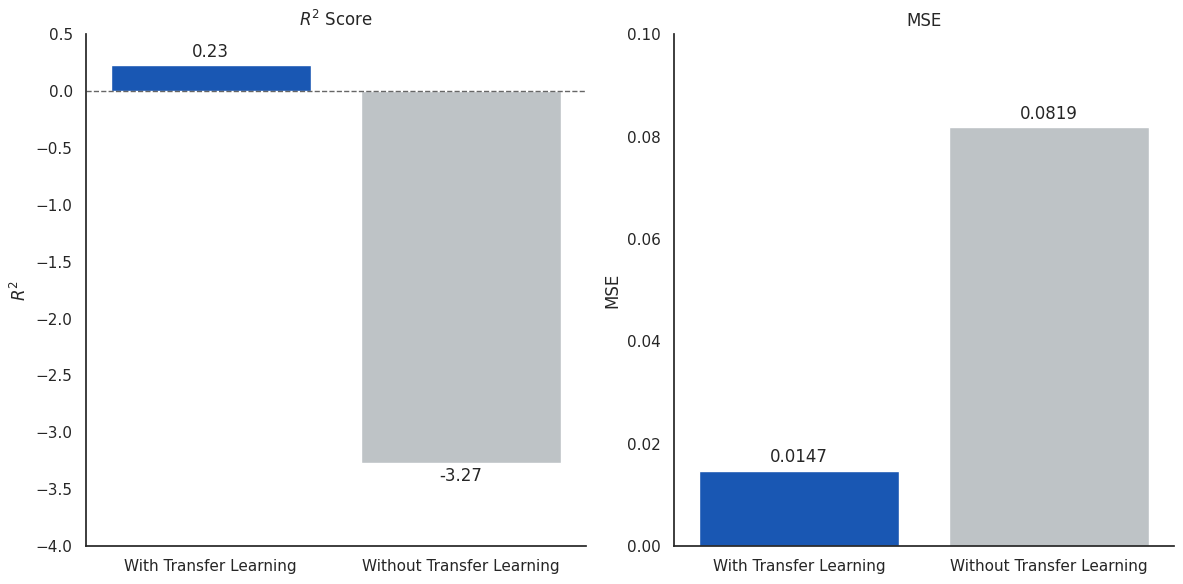

In [ ]:
# Create a two-panel figure for R2 and MSE comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Panel: R2 Score Comparison
sns.barplot(
    data=results_df_drug,
    x='Model',
    y='R2',
    palette=bar_palette_drug,
    ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3, fontsize=12)

axes[0].set_title('$R^2$ Score')
axes[0].set_ylabel('$R^2$')
axes[0].set_xlabel('')
axes[0].set_ylim(-4.0, 0.5)  # Adjusted for negative R2 values
axes[0].tick_params(axis='x', rotation=0)

# Right Panel: MSE Comparison
sns.barplot(
    data=results_df_drug,
    x='Model',
    y='MSE',
    palette=bar_palette_drug,
    ax=axes[1]
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3, fontsize=12)

axes[1].set_title('MSE')
axes[1].set_ylabel('MSE')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 0.1)      # Adjusted for the drug MSE scale
axes[1].tick_params(axis='x', rotation=0)

# Final layout adjustments
sns.despine()
plt.tight_layout()
plt.show()

### Pathway activation landscape across drugs

In [ ]:
# Extract pathway activations using the pre-loaded transfer model
X_full_tensor_drug = torch.tensor(data_matrix_drug.to_numpy(), dtype=torch.float32)

transfer_model_drug.eval()
with torch.no_grad():
    # activations are the hidden pathway-layer outputs
    _, activations = transfer_model_drug(X_full_tensor_drug)

# Convert to DataFrame and drop the 'others' auxiliary neuron/pathway
pathway_activations_df = pd.DataFrame(
    activations,
    index=data_matrix_drug.index,
    columns=mask.columns
).drop(columns=['others'])

In [ ]:
# Aggregate importance by drug and calculate Z-scores
drug_pathway_importance_df = pathway_activations_df.join(sample_info_drug['cmap_name']).groupby('cmap_name').mean()
drug_pathway_importance_df.index.name = "drug"

z_scored_pathway_importance = (drug_pathway_importance_df - drug_pathway_importance_df.mean()) / drug_pathway_importance_df.std()

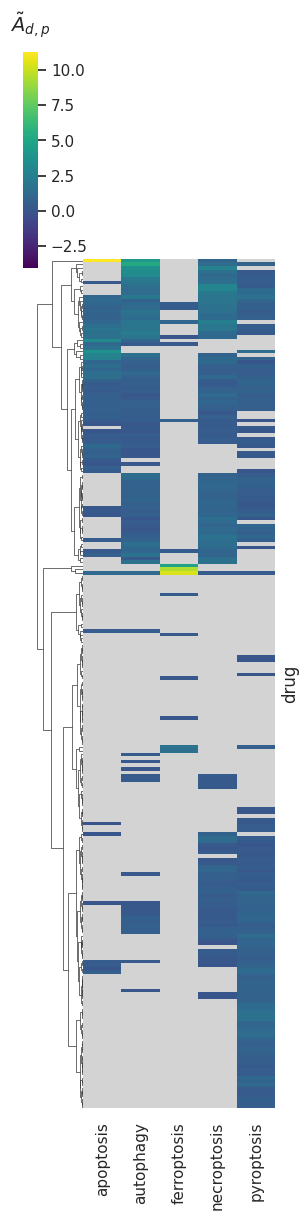

In [ ]:
# Mask negative values to focus only on positive associations (activation higher than mean)
v_min = z_scored_pathway_importance.values.min()
v_max = z_scored_pathway_importance.values.max()
negative_z_mask = (z_scored_pathway_importance < 0)

# Visualize drug-pathway importance via Clustermap
clustermap_g = sns.clustermap(
    z_scored_pathway_importance,
    method='ward',
    metric='euclidean',
    cmap='viridis',
    mask=negative_z_mask,
    vmin=v_min,
    vmax=v_max,
    row_cluster=True,
    col_cluster=False,
    figsize=(3, 12),
    yticklabels=False
)

clustermap_g.cax.set_title(r'$\tilde{A}_{d, p}$', fontsize=14, pad=15)
clustermap_g.ax_heatmap.set_ylabel("drug", fontsize=12)
clustermap_g.ax_heatmap.set_facecolor('lightgrey')
plt.show()

In [ ]:
# Display top 10 Drug-Pathway pairs by Z-score
top_pathway_drug_pairs = z_scored_pathway_importance.unstack().sort_values(ascending=False).head(10)

print("Top 10 Drug-Pathway Associations:")
for (pathway, drug), z_val in top_pathway_drug_pairs.items():
    raw_val = drug_pathway_importance_df.loc[drug, pathway]
    print(f"Drug: {drug:18} | Pathway: {pathway:12} | Z-score: {z_val:6.2f} | Raw Importance: {raw_val:.4f}")

Top 10 Drug-Pathway Associations:
Drug: BRD-K19103580      | Pathway: apoptosis    | Z-score:  11.28 | Raw Importance: 0.0869
Drug: decitabine         | Pathway: ferroptosis  | Z-score:  10.39 | Raw Importance: 0.0092
Drug: SCH-79797          | Pathway: ferroptosis  | Z-score:   9.47 | Raw Importance: 0.0084
Drug: BRD-K34485477      | Pathway: autophagy    | Z-score:   5.29 | Raw Importance: 0.1763
Drug: BMS-754807         | Pathway: ferroptosis  | Z-score:   4.84 | Raw Importance: 0.0044
Drug: BRD-K19103580      | Pathway: autophagy    | Z-score:   4.14 | Raw Importance: 0.1446
Drug: fulvestrant        | Pathway: apoptosis    | Z-score:   3.77 | Raw Importance: 0.0311
Drug: BRD-K78574327      | Pathway: autophagy    | Z-score:   3.58 | Raw Importance: 0.1291
Drug: BRD-K13999467      | Pathway: autophagy    | Z-score:   3.32 | Raw Importance: 0.1219
Drug: rigosertib         | Pathway: apoptosis    | Z-score:   3.29 | Raw Importance: 0.0276
